# 03 Results
**Author:** Elif Yegenoglu

Every figure and table in the deck: permutation importance, parsimony curves, within-country AUCs,
confusion matrices, ROC/PR, distribution plots, and the odds-ratio forest plots. Figures save to
`Data/output/`. Standalone - the setup block reruns the pipeline from `02_model.ipynb`.

> **Shared setup.** The cells down to CELL 7 are copied verbatim from `02_model.ipynb` so this
> notebook runs standalone (separate notebooks = separate kernels). If the pipeline changes in 02,
> re-copy these cells. Everything after the setup block is this notebook's own content.

In [ ]:
# ============================================================
# CELL 0 — paths (portable: finds the repo by walking up from cwd)
# No editing needed on any machine. If it errors, open the repo
# folder itself in VS Code / Jupyter and restart the kernel.
# ============================================================
from pathlib import Path

def find_root(start=None, depth=6):
    p = start or Path.cwd()
    for _ in range(depth):
        if (p / "Data").exists() and (p / "Model").exists():
            return p
        p = p.parent
    raise FileNotFoundError(
        f"repo root not found walking up from {Path.cwd()} — "
        "in VS Code use File > Open Folder on summer26-teacher-ai-readiness, "
        "reopen this notebook, restart the kernel")

ROOT = find_root()
DATA_DIR = ROOT / "Data"                 # codebook + small CSVs
SPSS_DIR = DATA_DIR / "SPSS"             # raw TALIS .sav files (gitignored)
OUT_DIR  = DATA_DIR / "output"           # everything the notebooks produce (gitignored)
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("repo root:", ROOT)

repo root: c:\Users\elif_\Documents\summer26-teacher-ai-readiness


In [2]:
import matplotlib.pyplot as plt   # figures below need it (in 02 it arrives with the bake-off cell)

## Building the AI-module analysis sample

Q36 ("Have you used AI in your teaching?") is a **rotated** survey item, so a non-answer can mean two very different things:

- **Code 8 — "not administered":** a random ~2/3 of teachers never saw the question by design. This is *not missing data* — they were never asked — so we filter these rows out explicitly.
- **Code 9 — "omitted":** teachers who *were* asked but declined to answer.
  This is genuine outcome-missingness. We mark it `NaN` (rather than dropping
  it here) so it flows through the same complete-case filter as every other
  missing value in the assembly step.

Keeping the omitted rows at this stage keeps "not administered" and "declined"
conceptually distinct, and lets us count the omitters before they're dropped.

In [3]:
# ============================================================
# CELL 1 — load merged file, build ai_sample
# ============================================================
import re
import numpy as np
import pandas as pd

merged = pd.read_csv(DATA_DIR / "output" / "teacher_principal_named_columns.csv",
                     encoding="utf-8-sig", low_memory=False)
assert any(c.startswith("P_TC") for c in merged.columns), "no principal columns - wrong file?"

q36_col = next(c for c in merged.columns if c.startswith("TT4G36"))
q36_num = pd.to_numeric(merged[q36_col], errors="coerce")
ai_sample = merged[q36_num != 8].copy()
ai_sample[q36_col] = pd.to_numeric(ai_sample[q36_col], errors="coerce").replace(9, np.nan)
print("administered the AI module:", len(ai_sample))

administered the AI module: 92894


## Selecting teacher features (RQ1)

From the exploratory correlation screen (see `q36_correlations.xlsx`) plus technology-adoption theory, we select **18 teacher-level features**, one per construct, to predict AI adoption.

**We deliberately drop some candidates to avoid redundancy** — including a variable that duplicates another only inflates the model and splits its
importance across correlated columns:

- **Self-efficacy** — the subscales (T4SECLS/SEINS/SEENG) *and* overall
  **T4SELF** → we keep only **TT4G27M** (digital self-efficacy), the AI-relevant
  facet. General teaching confidence isn't specific to technology, so it's a
  weaker fit for predicting AI adoption.
- **T4JOYTCH** → dropped; near-duplicate of **T4JOBSAT** (r ≈ 0.6).
- **T4WELS** (umbrella wellbeing) → dropped in favour of the specific stress
  scales (**T4WLOADT**, **T4STBEH**).
- **T4EXINF**, **TT4G10** → dropped; overlap with **T4COLES** and **T4TNSCH**.
- **The TT4G16 hours battery** → collapsed to a single hours variable (**TT4G15**);
  the rest were near-zero in the screen.
- **TT4G50A–C** → dropped entirely (no overlap with the Q36 rotation form).

We build two derived features:
- **`prep_general`** — the mean of the six general-preparation items (TT4G07A–E, G),
  so "digital preparedness" (TT4G07F) stays a distinct predictor rather than
  being diluted by the whole battery.
- **AI-belief composites** — the ten belief items (TT4G35A–J, scored 1–4;
  code 5 = "I don't know" recoded to missing) are averaged into
  **`ai_benefit_mean`** (items A–E) and **`ai_risk_mean`** (items F–J), giving
  two interpretable scores instead of ten correlated columns.

We also constructed teacher–principal **disagreement measures** (perception gaps in participation, leadership, satisfaction), but these showed no predictive
signal in preliminary analysis and were dropped.

---

**Reasoning behind the feature selection.** The features chosen map onto established technology-adoption frameworks (TAM, Davis 1989; UTAUT,
Venkatesh et al. 2003): perceived usefulness (`ai_benefit_mean`), ease of use (`TT4G27M`, `TT4G07F`), social influence (`T4COLES`, `T4VALP`), facilitating
conditions (`TT4G21G`, AI training), and demographic moderators (`T4TAGEGR`).TALIS items serve as proxies for these constructs rather than validated scales.

In [4]:
# ============================================================
# CELL 2 — teacher features (RQ1) + prep_general + belief composites
# Definitions = official TALIS 2024 codebook labels (abbreviated)
# ============================================================
cb = pd.read_csv(DATA_DIR / "talis2024_teacher_codebook.csv")

def tcol(v):
    """short code -> actual teacher column name in merged/ai_sample"""
    return next(c for c in ai_sample.columns if c.startswith(v + " ") or c == v)

# --- AI-belief COMPOSITES (mean of items; code 5 "I don't know" -> missing) ---
# Q35 scale: 1=Strongly disagree ... 4=Strongly agree, 5=I don't know (NOT on scale)
def belief_mean(items):
    B = ai_sample[[tcol(v) for v in items]].apply(pd.to_numeric, errors='coerce')
    B = B.replace(5, 2.5)                       # ← THIS LINE: "don't know" (5) -> neutral 2.5
    B = B.where(B.isin([1, 2, 2.5, 3, 4]))      # ← note 2.5 added to valid values
    return B.mean(axis=1).where(B.notna().sum(axis=1) >= 1)
ai_sample['ai_benefit_mean'] = belief_mean([f'TT4G35{c}' for c in 'ABCDE'])  # benefits
ai_sample['ai_risk_mean']    = belief_mean([f'TT4G35{c}' for c in 'FGHIJ'])  # risks/concerns

# --- general pedagogical preparation composite ---
# Q7a-e,g: prepared for content / subject pedagogy / general pedagogy /
# classroom practice / multicultural settings / student development
prep_codes = ['TT4G07A', 'TT4G07B', 'TT4G07C', 'TT4G07D', 'TT4G07E', 'TT4G07G']
P = ai_sample[[tcol(v) for v in prep_codes]].apply(pd.to_numeric, errors='coerce')
P = P.where(~P.isin([6, 8, 9]))
ai_sample['prep_general'] = P.mean(axis=1).where(P.notna().sum(axis=1) >= 4)

feature_cols = (
    # --- AI / digital core ---
    ['TT4G21G',   # Q21g: professional learning included "using AI for teaching and learning" (yes/no)
     'TT4G07F',   # Q7f: felt prepared for "use of digital resources and tools" (initial education)
     'TT4G27M']   # Q27m: self-efficacy — support learning through digital resources and tools

    # --- AI beliefs: two COMPOSITE scores (replaces the 10 Q35 items) ---
    + ['ai_benefit_mean',  # mean of Q35A-E; higher = agrees AI is beneficial
       'ai_risk_mean']     # mean of Q35F-J; higher = agrees AI is risky/concerning

    # --- derived: general pedagogical preparation ---
    + ['prep_general']

    # --- professional environment (TALIS derived scales) ---
    + ['T4COLES',   # Professional collaboration in lessons among teachers
       'T4TLEAD',   # Teacher leadership
       'T4VALP']    # Perceptions of value and policy influence
                    # NOTE: T4SELF (overall self-efficacy) dropped — overlaps with
                    # TT4G27M (digital self-efficacy), the AI-relevant facet we keep

    # --- wellbeing / stress (derived scales) ---
    + ['T4JOBSAT',  # Job satisfaction, overall
       'T4WLOADT',  # Workload stress
       'T4STBEH',   # Student behaviour stress
       'T4CHFAT']   # Change fatigue

    # --- workload ---
    + ['TT4G15']    # Q15: hours teaching at this school, most recent full week

    # --- demographics / employment (grouped) ---
    + ['T4TAGEGR',  # Teacher age (grouped)
       'T4TEMPWH',  # Employment status by working hours (grouped; CATEGORICAL)
       'T4TNSCH']   # Number of schools the teacher works at

    # --- structure ---
    + ['CNTRY']     # Country alpha code (CATEGORICAL, fixed effect)
)

withlabels = {
    'TT4G21G':         'Received AI Training',
    'ai_benefit_mean': 'AI-benefit beliefs',
    'ai_risk_mean':    'AI-risk beliefs',
    'CNTRY':           'Country',
    'TT4G27M':         'Digital self-efficacy',
    'TT4G07F':         'Digital preparedness',
    'prep_general':    'General preparation',
    'T4TAGEGR':        'Age group',
    'T4COLES':         'Professional collaboration',
    'T4TLEAD':         'Teacher leadership',
    'T4VALP':          'Perceived value & influence',
    'T4JOBSAT':        'Job satisfaction',
    'T4WLOADT':        'Workload stress',
    'T4STBEH':         'Student-behaviour stress',
    'T4CHFAT':         'Change fatigue',
    'TT4G15':          'Teaching hours',
    'T4TEMPWH':        'Employment status',
    'T4TNSCH':         'Number of schools',
}

assert len(feature_cols) == len(set(feature_cols))
print("teacher features:", len(feature_cols))   # 18

teacher features: 18


In [5]:
# ---- sanity check (fast, safe to skip): recode loop handles every feature ----
DERIVED = ['prep_general', 'ai_benefit_mean', 'ai_risk_mean']
categoricals = ['CNTRY', 'T4SCHLOC', 'T4TEMPWH']

for v in feature_cols:
    if v in categoricals:
        status = 'categorical'
    elif v in DERIVED:
        status = 'derived (skip recode)'
    elif v in cb['variable_name'].values:
        status = 'raw + in codebook'
    else:
        status = 'WARNING: raw but NOT in codebook'
    print(f"{v:18s} {status}")

TT4G21G            raw + in codebook
TT4G07F            raw + in codebook
TT4G27M            raw + in codebook
ai_benefit_mean    derived (skip recode)
ai_risk_mean       derived (skip recode)
prep_general       derived (skip recode)
T4COLES            raw + in codebook
T4TLEAD            raw + in codebook
T4VALP             raw + in codebook
T4JOBSAT           raw + in codebook
T4WLOADT           raw + in codebook
T4STBEH            raw + in codebook
T4CHFAT            raw + in codebook
TT4G15             raw + in codebook
T4TAGEGR           raw + in codebook
T4TEMPWH           categorical
T4TNSCH            raw + in codebook
CNTRY              categorical


## Building the modeling sample

Here we assemble the final analysis table: the teacher features (recoding survey
missing-codes to `NaN`), attach the target `y` (1 = used AI, 0 = did not), and
keep only **complete cases** — teachers with valid values on every feature.

**Why complete-case?** The model needs all features present for each teacher, so
any row with a missing value is dropped. We report the accounting explicitly;
how many rows we start with, how many survive, and *where* the losses come from.
Because complete-case selection isn't random: teachers who skip items may differ
systematically, and a reader should see the trade-off.

We also check that no country is disproportionately dropped (which would quietly
narrow what our cross-national claims cover) and that no country cell becomes too
small to model reliably. A useful check is whether the complete-case **AI-use
rate** matches the full-sample rate: if the two diverge, complete-casing is
biasing the sample toward one kind of teacher.

**Why school variables are handled separately.** Several countries (e.g. Japan,
Poland, Iceland, the Netherlands) do not report the full set of principal
(school) variables, so requiring them would drop those systems entirely and
skew the sample toward higher-data countries. We therefore keep the main model
to **teacher-level features**  retaining broad country coverage and run the
school-context comparison separately, on the subset of teachers with complete
principal data (see the school-context section). In the current sample, Teacher's age group is missing from Singapoure respondents but we kept at the cost of it since it came as a strong predictor. 

In [6]:
# ============================================================
# CELL 4 — assembly: ONE fixed complete-case sample + accounting
# ============================================================
def col_for(v):
    if v in ai_sample.columns:          # prep_general, composites
        return v
    return tcol(v)

all_short = feature_cols #+ school_block           # teacher features only (school block is for subset analysis)
D = ai_sample[[col_for(v) for v in all_short]].copy()
D.columns = all_short

# per-variable missing codes from the codebook (raw teacher vars only)
cb_codes = {}
for _, row in cb[cb.variable_name.isin(feature_cols)].iterrows():
    cb_codes[row.variable_name] = [float(x) for x in
        re.findall(r"(\d+)\s*=", str(row.special_missing_or_skip_codes))]

categoricals = ['CNTRY', 'T4SCHLOC', 'T4TEMPWH']
DERIVED = ['prep_general', 'ai_benefit_mean', 'ai_risk_mean']   # ← already clean, skip
for v in feature_cols:
    if v in categoricals or v in DERIVED:                        # ← was: == 'prep_general'
        continue
    D[v] = pd.to_numeric(D[v], errors='coerce')
    if cb_codes.get(v):
        D[v] = D[v].where(~D[v].isin(cb_codes[v]))

D['TT4G21G'] = D['TT4G21G'].map({1: 1, 2: 0})     # yes/no -> 1/0

D['y'] = (pd.to_numeric(ai_sample[q36_col], errors='coerce') == 1).astype(float)
D.loc[ai_sample[q36_col].isna(), 'y'] = np.nan
D['IDSCHOOL'] = ai_sample[next(c for c in ai_sample.columns if c.startswith('IDSCHOOL'))]
D['CNTRY'] = D['CNTRY'].astype(str).str.strip()
D['T4TEMPWH'] = pd.to_numeric(D['T4TEMPWH'], errors='coerce').where(
    lambda s: ~s.isin([8, 9]))

# ---- missingness accounting ----
n0 = len(D)
print("worst 10 columns by missingness (%):")
print(D[all_short].isna().mean().mul(100).round(1).sort_values(ascending=False).head(10).to_string())

data = D.dropna()
print(f"\ncomplete cases: {len(data):,} of {n0:,}  ({len(data)/n0*100:.1f}%)")
print(f"AI-use rate: full {D['y'].mean():.3f}  |  complete-case {data['y'].mean():.3f}")

kept = pd.Series(D.index.isin(data.index), index=D.index)
drop_by_cntry = (1 - kept.groupby(D['CNTRY']).mean()).mul(100).round(1)
print("\ncountries losing the most rows (%):")
print(drop_by_cntry.sort_values(ascending=False).head(8).to_string())

for v in ['T4TAGEGR', 'TT4G21G']:
    print(f"{v}: kept mean {D.loc[kept, v].mean():.3f} | dropped mean {D.loc[~kept, v].mean():.3f}")

cc = data['CNTRY'].value_counts()
print("\nsmallest country cells:", cc.tail(3).to_dict())
print("countries with <200 rows:", (cc < 200).sum())

worst 10 columns by missingness (%):
TT4G21G         7.0
T4VALP          3.7
T4JOBSAT        3.6
T4CHFAT         3.5
T4STBEH         3.5
T4WLOADT        3.4
TT4G07F         3.1
T4TLEAD         2.9
prep_general    2.8
TT4G15          2.6

complete cases: 75,817 of 92,894  (81.6%)
AI-use rate: full 0.409  |  complete-case 0.414

countries losing the most rows (%):
CNTRY
NLD    100.0
SGP    100.0
HRV     56.0
SAU     31.0
SWE     30.3
ISR     28.7
XKX     28.0
ZAF     27.0
T4TAGEGR: kept mean 2.877 | dropped mean 2.942
TT4G21G: kept mean 0.414 | dropped mean 0.437

smallest country cells: {'NOR': 380, 'ISL': 343, 'MNE': 340}
countries with <200 rows: 0


## Train/test split and modeling setup

**School-grouped split.** Teachers are nested in schools, and teachers from the same school are more alike than teachers from different schools. A naïve random
split would put some teachers from a school in training and others in test letting the model learn at each school's pattern and inflating our scores. Therefore, we split by **school**: every teacher from a given school lands entirely in training *or* test, never both. An assertion confirms no school appears on both sides. 

**Consistent preprocessing (no leakage).** All preprocessing — scaling numeric features, one-hot encoding categoricals (country, employment status) — lives inside a scikit-learn `Pipeline`, fit only on the training data, so the test set never influences how features are prepared. A school-grouped 70/30 split yielded 53,188 training and 23,574 test observations with near-identical outcome prevalence (41.3% vs. 41.1%), confirming the grouped split preserved class balance despite not being stratified.

In [ ]:
# ============================================================
# CELL 5 — school-grouped split + helpers (used by all comparisons)
# ============================================================
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score
from scipy.stats import norm

RANDOM_STATE = 42
CATEGORICALS = ['CNTRY', 'T4TEMPWH']          # T4SCHLOC gone (school block out)

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss.split(data, data['y'], groups=data['IDSCHOOL']))
train, test = data.iloc[tr_idx], data.iloc[te_idx]
assert not (set(train['IDSCHOOL']) & set(test['IDSCHOOL'])), "schools leak!"
print(f"train {len(train):,} | test {len(test):,}")
print(f"AI share — train {train['y'].mean():.3f} | test {test['y'].mean():.3f}")

def make_pipe(feats, clf=None):
    cat = [c for c in feats if c in CATEGORICALS]
    num = [c for c in feats if c not in CATEGORICALS]
    steps = [('num', StandardScaler(), num)]
    if cat:
        steps.append(('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat))
    if clf is None:
        clf = GradientBoostingClassifier(random_state=RANDOM_STATE)
    return Pipeline([('prep', ColumnTransformer(steps)), ('clf', clf)])


HEADLINE_CLF = lambda: GradientBoostingClassifier(random_state=RANDOM_STATE)

def delong(y, p1, p2):
    y = np.asarray(y); pos, neg = y == 1, y == 0
    m, n = pos.sum(), neg.sum()
    def struct(p):
        x, yv = p[pos], p[neg]
        v10 = np.array([(np.sum(xi > yv) + .5*np.sum(xi == yv))/n for xi in x])
        v01 = np.array([(np.sum(x > yi) + .5*np.sum(x == yi))/m for yi in yv])
        return v10, v01, v10.mean()
    a1v,a1w,a1 = struct(np.asarray(p1)); a2v,a2w,a2 = struct(np.asarray(p2))
    s10 = np.cov(np.vstack([a1v,a2v])); s01 = np.cov(np.vstack([a1w,a2w]))
    var = (s10[0,0]+s10[1,1]-2*s10[0,1])/m + (s01[0,0]+s01[1,1]-2*s01[0,1])/n
    z = (a1-a2)/np.sqrt(var) if var > 0 else 0.0
    return a1, a2, 2*norm.sf(abs(z))

train 52,533 | test 23,284
AI share — train 0.414 | test 0.412


## Nested feature comparison

Instead of fitting one model and reading off coefficients, we build the model in
**nested tiers** — adding one conceptual block at a time, on the *same teachers*
and the *same train/test split* — and measure how much each block improves
discrimination (ROC-AUC). The gain (ΔAUC) at each step shows what that block
actually contributes.

- **A — teacher traits:** demographics, self-efficacy, collaboration, wellbeing,
  preparation — characteristics that plausibly *predate* AI adoption. This is our
  "cleanest" tier, least entangled with the outcome.
- **A + T — add AI training:** does professional development in AI predict use?
- **A + T + Bb / Br — add belief composites separately:** benefit beliefs and
  risk beliefs entered one at a time, so we can see which kind of belief carries
  the signal.
- **A + T + B — add both belief composites.**

Two features are deliberately held out of Tier A because they are the most
**entangled with the outcome**: AI training (a teacher inclined toward AI may
seek out AI training) and AI beliefs (using AI shapes what a teacher believes
about it). Measured in the same survey wave, these can't be read causally — so
Tier A gives the honest "how predictable is adoption from things adoption didn't
cause?" baseline, and the later tiers show how much predictive (not causal)
signal training and beliefs add.

## How well can we predict AI adoption — and what drives it?

We measure model quality with **ROC-AUC**: the probability the model ranks a random AI-user above a random non-user. 0.5 = coin flip, 1.0 = perfect.

**Building the model in tiers.** Rather than one black-box model, we add feature groups one at a time and watch how much each improves AUC. The *gain* at eachstep is the finding — a group that doesn't move the number, doesn't matter:

| Tier | What it adds |
|------|--------------|
| **Dummy** | baseline (random guessing) — the floor |
| **A=teacher traits** | who the teacher is (efficacy, collaboration, wellbeing, prep) |
| **A + Training** | did their professional development cover AI? |
| **A + T + Benefit beliefs** | do they think AI is useful? |
| **A + T + Risk beliefs** | do they worry about AI's risks? |
| **A + T + All beliefs** | both belief types together |


In [ ]:
# ============================================================
# CELL 6 — nested model tiers
# ============================================================
# Tier A = "pre-adoption" traits: exclude AI training and belief composites
# (the features most entangled with the outcome), keep the rest.
tier_a = [c for c in feature_cols
          if c != 'TT4G21G' and c not in ('ai_benefit_mean', 'ai_risk_mean')]

feature_sets = {
    'A: teacher traits':        tier_a,
    'A+T: +AI training':        tier_a + ['TT4G21G'],
    'A+T+Bb: +benefit beliefs': tier_a + ['TT4G21G', 'ai_benefit_mean'],
    'A+T+Br: +risk beliefs':    tier_a + ['TT4G21G', 'ai_risk_mean'],
    'A+T+B: +all beliefs':      tier_a + ['TT4G21G', 'ai_benefit_mean', 'ai_risk_mean'],
}
for k, v in feature_sets.items():
    print(f"{k:28s} {len(v)} features")

A: teacher traits            15 features
A+T: +AI training            16 features
A+T+Bb: +benefit beliefs     17 features
A+T+Br: +risk beliefs        17 features
A+T+B: +all beliefs          18 features


## Nested comparison: what drives adoption?

We fit each tier on the training set and score it on the held-out test set, building up from the baseline. Each step's AUC gain shows how much that feature
block contributes.

**Two honesty checks run alongside:**
- **DeLong tests** — when a belief block adds only a small AUC bump, DeLong tells us whether that gain is statistically real or just noise. We report both the *size* of the gain and its p-value, because with a large test set even trivial differences can be "significant" — the size is what tells us if it matters.
- **Null-target test** — we shuffle the outcome labels and refit; a clean model should collapse to AUC ≈ 0.5, since there's nothing real to learn. If it scored higher, something would be leaking. (Ours passes.)

The dummy baseline sits at 0.498, confirming chance-level is ~0.50 and everything above it reflects real signal. Teacher traits alone reach 0.709, demographics/background carry meaningful information. Adding AI training lifts it to 0.777, a solid increment. Adding benefit beliefs gives the biggest jump (0.777 → 0.833), while risk beliefs alone add less (0.777 → 0.793). The full model tops out at 0.835.

In [9]:
# ============================================================
# CELL 7 — nested comparison + null-target check
# ============================================================
fitted = {}
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy.fit(train[tier_a], train['y'])
print(f"{'dummy baseline':<28} "
      f"{roc_auc_score(test['y'], dummy.predict_proba(test[tier_a])[:,1]):.3f}")

for name, feats in feature_sets.items():
    pipe = make_pipe(feats).fit(train[feats], train['y'])
    proba = pipe.predict_proba(test[feats])[:, 1]
    fitted[name] = (pipe, feats, proba)
    print(f"{name:<28} {roc_auc_score(test['y'], proba):.3f}")

# incremental belief tests
_, _, p_b = delong(test['y'].values, fitted['A+T+Bb: +benefit beliefs'][2],
                   fitted['A+T+B: +all beliefs'][2])
_, _, p_r = delong(test['y'].values, fitted['A+T+Br: +risk beliefs'][2],
                   fitted['A+T+B: +all beliefs'][2])
print(f"\nbenefits->all: DeLong p={p_b:.2e}  (does RISK add beyond benefits?)")
print(f"risks->all:    DeLong p={p_r:.2e}  (does BENEFIT add beyond risks?)")

# null-target leakage check
y_shuf = train['y'].sample(frac=1, random_state=0).values
full = feature_sets['A+T+B: +all beliefs']
null_auc = roc_auc_score(test['y'],
    make_pipe(full).fit(train[full], y_shuf).predict_proba(test[full])[:, 1])
print(f"\nnull-target AUC: {null_auc:.3f}  (expect ~0.50)")

dummy baseline               0.498
A: teacher traits            0.711
A+T: +AI training            0.778
A+T+Bb: +benefit beliefs     0.833
A+T+Br: +risk beliefs        0.793
A+T+B: +all beliefs          0.836

benefits->all: DeLong p=2.45e-11  (does RISK add beyond benefits?)
risks->all:    DeLong p=6.95e-109  (does BENEFIT add beyond risks?)

null-target AUC: 0.460  (expect ~0.50)


## What predicts teacher AI adoption?

We measure each feature's importance by **permutation**: shuffle one feature's
values in the held-out test set and see how much AUC drops. A large drop means
the model relied heavily on that feature; near-zero means it added nothing. We
use permutation (rather than the model's built-in importance) because it's
measured on held-out data and doesn't unfairly reward high-cardinality features
like country.

**Three features carry almost all the signal:**

- **AI-benefit beliefs (0.137)** — believing AI is useful is by far the strongest
  predictor of adoption, more than the next two combined.
- **AI training (0.078)** — whether professional development covered AI is second.
- **Country (0.026)** — where a teacher works matters, but far less than their
  beliefs or training.

Everything else — risk beliefs, self-efficacy, age, wellbeing, workload — is
near zero. The takeaway is a clean technology-adoption story: **teachers adopt AI
when they believe it's useful and when they've been trained on it.** Perceived
usefulness dominates, exactly as adoption theory (TAM) predicts.

*Caveat: beliefs and use were measured in the same survey wave, so these are
strong predictive associations, not proven causes — enthusiastic adopters may
both seek training and rate AI favourably.*

        feature      auc_drop           sd
ai_benefit_mean  1.338523e-01 2.575251e-03
        TT4G21G  7.941266e-02 1.565807e-03
          CNTRY  2.616132e-02 9.762351e-04
   ai_risk_mean  6.185015e-03 3.029337e-04
        TT4G27M  4.946861e-03 3.111655e-04
       T4TAGEGR  4.822238e-03 4.726133e-04
        T4COLES  1.064722e-03 2.583896e-04
       T4WLOADT  5.871555e-04 1.376055e-04
         T4VALP  4.399930e-04 1.112861e-04
        T4CHFAT  1.729043e-04 4.466008e-05
        T4TLEAD  1.530308e-04 6.324200e-05
   prep_general  9.895764e-05 3.215974e-05
         TT4G15  8.499506e-05 2.782412e-05
        T4STBEH  4.179259e-05 4.807395e-05
       T4TEMPWH  0.000000e+00 0.000000e+00
        T4TNSCH -2.230542e-07 6.717039e-07
        TT4G07F -7.324627e-06 2.633238e-05
       T4JOBSAT -1.354083e-05 2.921850e-05


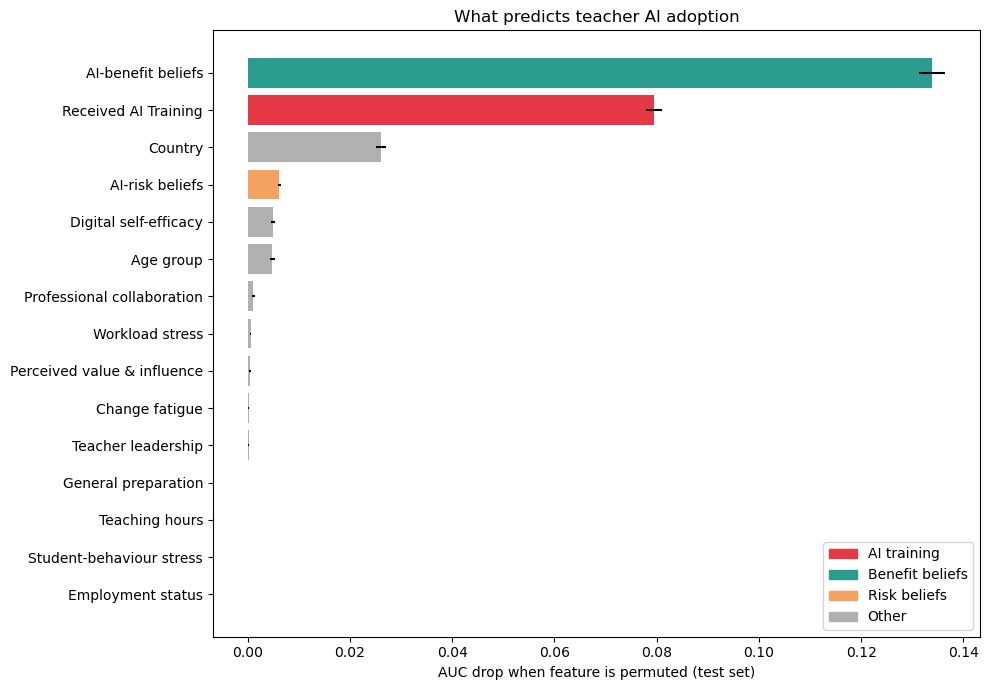

In [10]:
# ============================================================
# CELL 8 — permutation importance (test set)
# ============================================================
from sklearn.inspection import permutation_importance
from matplotlib.patches import Patch

best_name = 'A+T+B: +all beliefs'
best, best_feats, proba = fitted[best_name]

r = permutation_importance(best, test[best_feats], test['y'],
                           scoring='roc_auc', n_repeats=10,
                           random_state=RANDOM_STATE, n_jobs=-1)

imp = (pd.DataFrame({'feature': best_feats,
                     'auc_drop': r.importances_mean,
                     'sd': r.importances_std})
         .sort_values('auc_drop', ascending=False)
         .reset_index(drop=True))
print(imp.head(20).to_string(index=False))

# --- labels for the CURRENT feature set (composites, no T4SELF) ---
withlabels = {
    'TT4G21G':         'Received AI Training',
    'ai_benefit_mean': 'AI-benefit beliefs',
    'ai_risk_mean':    'AI-risk beliefs',
    'CNTRY':           'Country',
    'TT4G27M':         'Digital self-efficacy',
    'TT4G07F':         'Digital preparedness',
    'prep_general':    'General preparation',
    'T4TAGEGR':        'Age group',
    'T4COLES':         'Professional collaboration',
    'T4TLEAD':         'Teacher leadership',
    'T4VALP':          'Perceived value & influence',
    'T4JOBSAT':        'Job satisfaction',
    'T4WLOADT':        'Workload stress',
    'T4STBEH':         'Student-behaviour stress',
    'T4CHFAT':         'Change fatigue',
    'TT4G15':          'Teaching hours',
    'T4TEMPWH':        'Employment status',
    'T4TNSCH':         'Number of schools',
}

# --- color by family (composites, not individual items) ---
def fam_color(f):
    if f == 'TT4G21G':          return '#e63946'   # training — red
    if f == 'ai_benefit_mean':  return '#2a9d8f'   # benefit — teal
    if f == 'ai_risk_mean':     return '#f4a261'   # risk — amber
    return '#b0b0b0'                                # other — grey

top    = imp.head(15).iloc[::-1]
labels = top['feature'].map(withlabels).fillna(top['feature'])
colors = [fam_color(f) for f in top['feature']]

plt.figure(figsize=(10, 7))
plt.barh(labels, top['auc_drop'], xerr=top['sd'], color=colors)
plt.xlabel("AUC drop when feature is permuted (test set)")
plt.title("What predicts teacher AI adoption")
plt.legend(handles=[Patch(color='#e63946', label='AI training'),
                    Patch(color='#2a9d8f', label='Benefit beliefs'),
                    Patch(color='#f4a261', label='Risk beliefs'),
                    Patch(color='#b0b0b0', label='Other')],
           loc='lower right')
plt.tight_layout()
plt.savefig(DATA_DIR / "output" / "permutation_importance_labeled.png", dpi=150, bbox_inches="tight")
plt.show()

> *Setup for Part 2 objects (copied from `02_model.ipynb` CELLS 14–16): rebuilds the student-facing sample, split, model, and importance.*

In [11]:
# ============================================================
# CELL 9 — Part 2 target: student-facing AI use among users
# ============================================================
from sklearn.inspection import permutation_importance

STUDENT_FACING = ['TT4G37A', 'TT4G37G', 'TT4G37H']   # assess/mark, student data, practice
TEACHER_FACING = ['TT4G37B', 'TT4G37C', 'TT4G37F']   # summarise, lesson plans, comms
AMBIGUOUS      = ['TT4G37D', 'TT4G37E']              # SEN, auto-adjust -> sensitivity only
ALL37 = STUDENT_FACING + TEACHER_FACING + AMBIGUOUS

p2 = ai_sample[pd.to_numeric(ai_sample[q36_col], errors='coerce') == 1].copy()
for c in ALL37:
    p2[c] = pd.to_numeric(p2[tcol(c)], errors='coerce').map({1: 1, 2: 0})
p2 = p2.dropna(subset=STUDENT_FACING + TEACHER_FACING)   # must answer all 6 core items
print(f"AI users with complete purpose data: {len(p2):,}")

p2['y_core']  = p2[STUDENT_FACING].max(axis=1).astype(int)
p2['y_broad'] = p2[STUDENT_FACING + AMBIGUOUS].max(axis=1).fillna(p2['y_core']).astype(int)
print(f"base rate y_core:  {p2['y_core'].mean():.3f}")
print(f"base rate y_broad: {p2['y_broad'].mean():.3f}")
flipped = (p2['y_core'] != p2['y_broad']).mean()
print(f"y_broad flips {flipped*100:.1f}% of labels (sensitivity check)")

# teacher-facing-only (the holdout group): student-facing = 0
teacher_only = ((p2['y_core'] == 0) & (p2[TEACHER_FACING].max(axis=1) == 1)).mean()
print(f"teacher-facing only (no student-facing use): {teacher_only*100:.1f}%")
# ============================================================
# CELL 10 — Part 2 sample + grouped split (teacher features only)
# ============================================================
all_short = feature_cols                               # teacher-only, matches Part 1
D2 = p2[[col_for(v) for v in all_short]].copy()
D2.columns = all_short
for v in feature_cols:
    if v in CATEGORICALS or v in ('prep_general', 'ai_benefit_mean', 'ai_risk_mean'):
        continue
    D2[v] = pd.to_numeric(D2[v], errors='coerce')
    if cb_codes.get(v):
        D2[v] = D2[v].where(~D2[v].isin(cb_codes[v]))
D2['TT4G21G'] = D2['TT4G21G'].map({1: 1, 2: 0})
D2['y'] = p2['y_core'].values
D2['IDSCHOOL'] = p2[next(c for c in p2.columns if c.startswith('IDSCHOOL'))].values
D2['CNTRY'] = D2['CNTRY'].astype(str).str.strip()
D2['T4TEMPWH'] = pd.to_numeric(D2['T4TEMPWH'], errors='coerce')
D2.loc[D2['T4TEMPWH'].isin([8, 9]), 'T4TEMPWH'] = np.nan

data2 = D2.dropna()
print(f"Part 2 complete cases: {len(data2):,} ({len(data2)/len(D2)*100:.1f}%)")
print(f"positive rate: {data2['y'].mean():.3f} | trained share: {data2['TT4G21G'].mean():.3f}")

tri2, tei2 = next(GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
                  .split(data2, data2['y'], groups=data2['IDSCHOOL']))
train2, test2 = data2.iloc[tri2], data2.iloc[tei2]
assert not (set(train2['IDSCHOOL']) & set(test2['IDSCHOOL']))
print(f"train {len(train2):,} | test {len(test2):,}")

# ============================================================
# CELL 10b — Part 2 nested comparison + null-target check
# Mirrors CELL 7, with tiers redesigned to isolate CNTRY,
# since Part 2's question is context vs individual readiness.
# Requires: train2/test2 (CELL 10), make_pipe, HEADLINE_CLF,
#           delong, tier_a, feature_sets, DummyClassifier
# ============================================================
from sklearn.metrics import average_precision_score

tier_a_nc = [f for f in tier_a if f != 'CNTRY']      # teacher traits w/o country

feature_sets2 = {
    'C: country only':          ['CNTRY'],
    'A-C: traits (no country)': tier_a_nc,
    'A: traits + country':      tier_a,
    'A+T: +AI training':        tier_a + ['TT4G21G'],
    'A+T+B: +all beliefs':      feature_sets['A+T+B: +all beliefs'],
    'A+T+B-C: full, no country': [f for f in feature_sets['A+T+B: +all beliefs']
                                  if f != 'CNTRY'],
}

fitted2 = {}
dummy2 = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy2.fit(train2[tier_a], train2['y'])
d_proba = dummy2.predict_proba(test2[tier_a])[:, 1]
print(f"{'dummy baseline':<28} AUC {roc_auc_score(test2['y'], d_proba):.3f}")

print(f"{'tier':<28} {'AUC':>6} {'PR-AUC':>7}   (base rate {test2['y'].mean():.3f})")
for name, feats in feature_sets2.items():
    pipe = make_pipe(feats, HEADLINE_CLF()).fit(train2[feats], train2['y'])
    proba = pipe.predict_proba(test2[feats])[:, 1]
    fitted2[name] = (pipe, feats, proba)
    print(f"{name:<28} {roc_auc_score(test2['y'], proba):>6.3f} "
          f"{average_precision_score(test2['y'], proba):>7.3f}")

# --- the two comparisons that carry the Part 2 thesis ---
_, _, p_ctx = delong(test2['y'].values,
                     fitted2['C: country only'][2],
                     fitted2['A+T+B: +all beliefs'][2])
print(f"\ncountry-only vs full: DeLong p={p_ctx:.2e} "
      f"(do individual features add beyond country?)")

_, _, p_ind = delong(test2['y'].values,
                     fitted2['A+T+B-C: full, no country'][2],
                     fitted2['A+T+B: +all beliefs'][2])
print(f"no-country vs full:   DeLong p={p_ind:.2e} "
      f"(does country add beyond all individual features?)")

# --- null-target leakage check (same as Part 1) ---
y_shuf2 = train2['y'].sample(frac=1, random_state=0).values
full2 = feature_sets2['A+T+B: +all beliefs']
null_auc2 = roc_auc_score(
    test2['y'],
    make_pipe(full2, HEADLINE_CLF()).fit(train2[full2], y_shuf2)
        .predict_proba(test2[full2])[:, 1])
print(f"\nnull-target AUC: {null_auc2:.3f}  (expect ~0.50)")

# ============================================================
# CELL 11 — Part 2 model + PR-AUC (dual chart -> 03_results)
# ============================================================
from sklearn.metrics import average_precision_score

feats2 = feature_sets['A+T+B: +all beliefs']           # was +S: +school context
pipe2 = make_pipe(feats2, HEADLINE_CLF()).fit(train2[feats2], train2['y'])
proba2 = pipe2.predict_proba(test2[feats2])[:, 1]
print(f"ROC-AUC: {roc_auc_score(test2['y'], proba2):.3f}")
print(f"PR-AUC:  {average_precision_score(test2['y'], proba2):.3f} "
      f"(base rate {test2['y'].mean():.3f})")

r2 = permutation_importance(pipe2, test2[feats2], test2['y'],
                            scoring='roc_auc', n_repeats=10,
                            random_state=RANDOM_STATE, n_jobs=-1)
imp2 = (pd.DataFrame({'feature': feats2, 'auc_drop': r2.importances_mean})
          .sort_values('auc_drop', ascending=False).reset_index(drop=True))
print(imp2.head(15).to_string(index=False))

# quick Part 2 model check — does GB still win?
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

cv2 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for nm, clf in {'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
                'RandomForest': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE),
                'Logistic': LogisticRegression(max_iter=2000)}.items():
    s = cross_val_score(make_pipe(feats2, clf), train2[feats2], train2['y'],
                        cv=cv2, groups=train2['IDSCHOOL'], scoring='roc_auc', n_jobs=-1)
    print(f"{nm:18s} {s.mean():.3f} ± {s.std():.3f}")

AI users with complete purpose data: 35,708
base rate y_core:  0.698
base rate y_broad: 0.818
y_broad flips 12.0% of labels (sensitivity check)
teacher-facing only (no student-facing use): 26.2%
Part 2 complete cases: 30,689 (85.9%)
positive rate: 0.704 | trained share: 0.654
train 21,901 | test 8,788
dummy baseline               AUC 0.514
tier                            AUC  PR-AUC   (base rate 0.708)
C: country only               0.698   0.832
A-C: traits (no country)      0.682   0.829
A: traits + country           0.727   0.862
A+T: +AI training             0.729   0.863
A+T+B: +all beliefs           0.745   0.871
A+T+B-C: full, no country     0.714   0.847

country-only vs full: DeLong p=4.52e-24 (do individual features add beyond country?)
no-country vs full:   DeLong p=6.82e-25 (does country add beyond all individual features?)

null-target AUC: 0.479  (expect ~0.50)
ROC-AUC: 0.745
PR-AUC:  0.871 (base rate 0.708)
        feature  auc_drop
          CNTRY  0.067536
ai_benefit_me

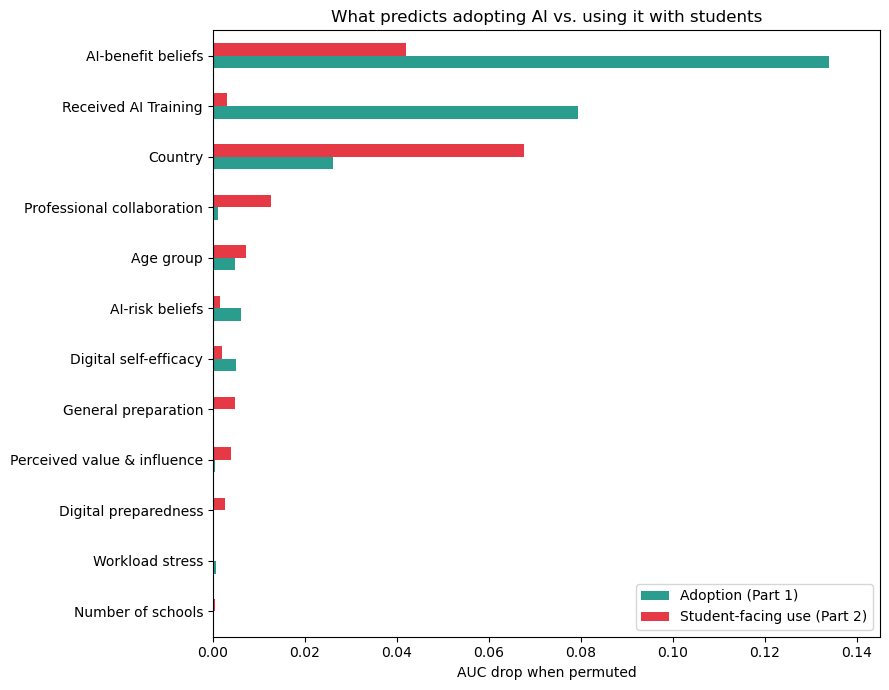

In [12]:
# ============================================================
# CELL 12 — dual importance chart: adoption vs student-facing (slide)
# Requires: imp + withlabels (CELL 10 above) and imp2 (CELL 14-16 above)
# ============================================================
# dual chart: what predicts ADOPTION vs STUDENT-FACING use
both = (imp.set_index('feature')['auc_drop'].rename('adoption').to_frame()
           .join(imp2.set_index('feature')['auc_drop'].rename('student_facing')))
both.index = [withlabels.get(f, f) for f in both.index]     # consistent labels
top_union = both.max(axis=1).sort_values(ascending=False).head(12).index
both.loc[top_union].iloc[::-1].plot.barh(figsize=(9, 7), color=["#2a9d8f", "#e63946"])
plt.xlabel("AUC drop when permuted")
plt.title("What predicts adopting AI vs. using it with students")
plt.legend(['Adoption (Part 1)', 'Student-facing use (Part 2)'], loc='lower right')
plt.xlim(0, 0.145)          # ← trim to just past the longest bar (AI-benefit at 0.137)
plt.tight_layout()
plt.savefig(DATA_DIR / "output" / "part1_vs_part2_importance.png", dpi=150, bbox_inches='tight')
plt.show()

## Parsimony Curve - How few questions do you actually need?

The full model uses 18 features but do we need all of them? We add features one at a time in order of importance and watch the AUC. The **marginal gain** column
shows what each new feature buys.

**Three features do almost all the work:**

- **AI-benefit beliefs** alone: AUC 0.754 (+0.254 over baseline)
- **+ AI training**: 0.807 (+0.053)
- **+ Country**: 0.827 (+0.020)

At three features the model already reaches 0.827 **higher than an 18-feature logistic regression (0.815)**. Every feature after the fifth adds thousandths of
a point; the curve is flat by then.

The practical implication: a policymaker doesn't need a 47-item survey to identif likely AI adopters. **Three questions** — does the teacher think AI is useful, have
they had AI training, and which country are they in — capture nearly all the predictable signal. Parsimony isn't just elegant here; it's actionable.

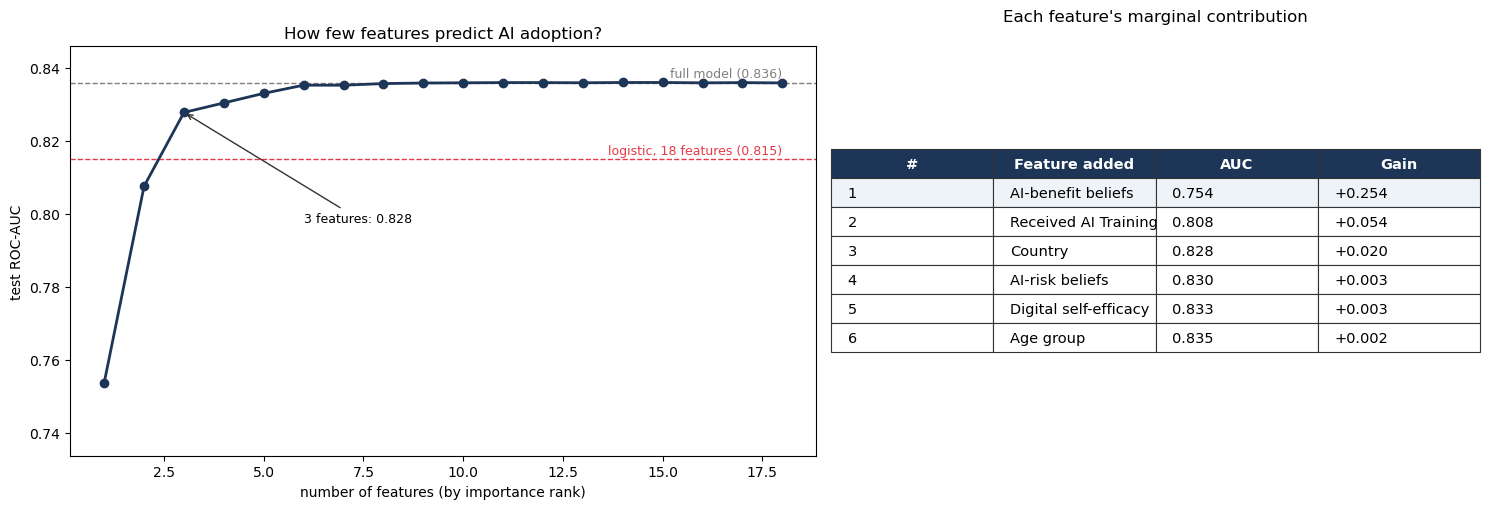

In [13]:
# ---- 13: parsimony curve + marginal-gain table, side by side ----
# reuses `withlabels` from the importance cell (one label source for the whole notebook)

ranked = imp['feature'].tolist()
step_rows, prev, curve = [], 0.5, []
for k in range(1, len(ranked) + 1):
    fk = ranked[:k]
    pk = (make_pipe(fk, HEADLINE_CLF()).fit(train[fk], train['y'])
          .predict_proba(test[fk])[:, 1])
    auc_k = roc_auc_score(test['y'], pk)
    curve.append((k, auc_k))
    if k <= 6:
        step_rows.append([k, withlabels.get(ranked[k-1], ranked[k-1]),
                          f"{auc_k:.3f}", f"+{auc_k - prev:.3f}"])
    prev = auc_k
pc = pd.DataFrame(curve, columns=['k', 'auc'])

LOGISTIC_AUC = 0.815
N_FEATURES = len(ranked)
full_auc = pc['auc'].iloc[-1]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 5.2),
                               gridspec_kw={'width_ratios': [1.15, 1]})

# LEFT: curve
axL.plot(pc['k'], pc['auc'], 'o-', color='#1d3557', lw=2, zorder=3)
axL.axhline(full_auc, color='grey', ls='--', lw=1)
axL.text(pc['k'].max(), full_auc + 0.0015, f'full model ({full_auc:.3f})',
         ha='right', fontsize=9, color='grey')
axL.axhline(LOGISTIC_AUC, color='#e63946', ls='--', lw=1)
axL.text(pc['k'].max(), LOGISTIC_AUC + 0.0015,
         f'logistic, {N_FEATURES} features ({LOGISTIC_AUC:.3f})',
         ha='right', fontsize=9, color='#e63946')
k3 = pc.loc[pc['k'] == 3, 'auc'].iloc[0]
axL.annotate(f'3 features: {k3:.3f}',
             xy=(3, k3), xytext=(6, k3 - 0.03),
             arrowprops=dict(arrowstyle='->', color='#333'), fontsize=9)
axL.set_xlabel("number of features (by importance rank)")
axL.set_ylabel("test ROC-AUC")
axL.set_title("How few features predict AI adoption?")
axL.set_ylim(pc['auc'].min() - 0.02, pc['auc'].max() + 0.01)

# RIGHT: table
axR.axis('off')
tbl = axR.table(cellText=step_rows, colLabels=['#', 'Feature added', 'AUC', 'Gain'],
                cellLoc='left', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10.5); tbl.scale(1, 1.7)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#333'); cell.set_linewidth(0.8)
    if r == 0:
        cell.set_facecolor('#1d3557'); cell.set_text_props(color='white', fontweight='bold')
    elif r == 1:
        cell.set_facecolor('#eef3f8')
axR.set_title("Each feature's marginal contribution", fontsize=12, pad=18)

plt.tight_layout()
plt.savefig(DATA_DIR / "output" / "parsimony_combined.png", dpi=150, bbox_inches='tight')
plt.show()

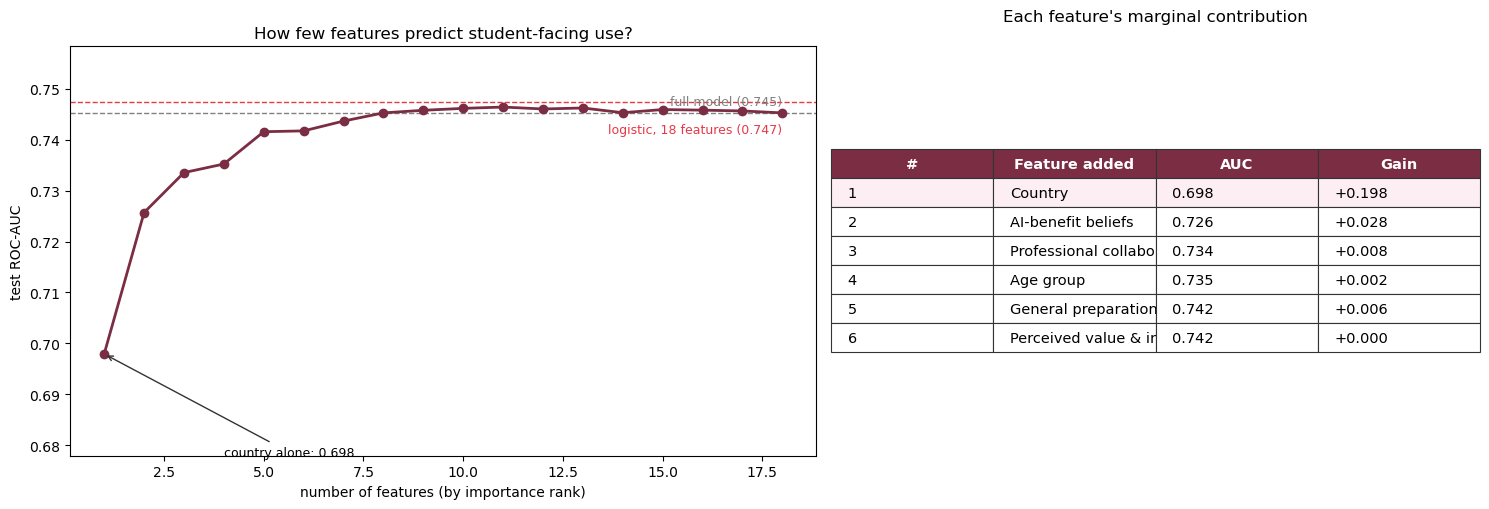

In [ ]:
# ============================================================
# CELL 14 — Part 2 parsimony curve + marginal-gain table
# Mirrors CELL 11 for the student-facing model.
# Requires: imp2, train2/test2, make_pipe, HEADLINE_CLF, withlabels
# ============================================================

ranked2 = imp2['feature'].tolist()
step_rows2, prev2, curve2 = [], 0.5, []
for k in range(1, len(ranked2) + 1):
    fk = ranked2[:k]
    pk = (make_pipe(fk, HEADLINE_CLF()).fit(train2[fk], train2['y'])
          .predict_proba(test2[fk])[:, 1])
    auc_k = roc_auc_score(test2['y'], pk)
    curve2.append((k, auc_k))
    if k <= 6:
        step_rows2.append([k, withlabels.get(ranked2[k-1], ranked2[k-1]),
                           f"{auc_k:.3f}", f"+{auc_k - prev2:.3f}"])
    prev2 = auc_k
pc2 = pd.DataFrame(curve2, columns=['k', 'auc'])

# logistic reference computed, not hard-coded
from sklearn.linear_model import LogisticRegression
log_auc2 = roc_auc_score(
    test2['y'],
    make_pipe(feats2, LogisticRegression(max_iter=2000))
        .fit(train2[feats2], train2['y'])
        .predict_proba(test2[feats2])[:, 1])

full_auc2 = pc2['auc'].iloc[-1]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 5.2),
                               gridspec_kw={'width_ratios': [1.15, 1]})

axL.plot(pc2['k'], pc2['auc'], 'o-', color='#7b2d43', lw=2, zorder=3)
axL.axhline(full_auc2, color='grey', ls='--', lw=1)
axL.text(pc2['k'].max(), full_auc2 + 0.0015, f'full model ({full_auc2:.3f})',
         ha='right', fontsize=9, color='grey')
axL.axhline(log_auc2, color='#e63946', ls='--', lw=1)
axL.text(pc2['k'].max(), log_auc2 - 0.006,
         f'logistic, {len(ranked2)} features ({log_auc2:.3f})',
         ha='right', fontsize=9, color='#e63946')
k1 = pc2.loc[pc2['k'] == 1, 'auc'].iloc[0]
axL.annotate(f'country alone: {k1:.3f}',
             xy=(1, k1), xytext=(4, k1 - 0.02),
             arrowprops=dict(arrowstyle='->', color='#333'), fontsize=9)
axL.set_xlabel("number of features (by importance rank)")
axL.set_ylabel("test ROC-AUC")
axL.set_title("How few features predict student-facing use?")
axL.set_ylim(pc2['auc'].min() - 0.02, pc2['auc'].max() + 0.012)

axR.axis('off')
tbl = axR.table(cellText=step_rows2,
                colLabels=['#', 'Feature added', 'AUC', 'Gain'],
                cellLoc='left', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10.5); tbl.scale(1, 1.7)
for (r, c_), cell in tbl.get_celld().items():
    cell.set_edgecolor('#333'); cell.set_linewidth(0.8)
    if r == 0:
        cell.set_facecolor('#7b2d43')
        cell.set_text_props(color='white', fontweight='bold')
    elif r == 1:
        cell.set_facecolor('#fdeef4')
axR.set_title("Each feature's marginal contribution", fontsize=12, pad=18)

plt.tight_layout()
plt.savefig(DATA_DIR / "output" / "parsimony_combined_part2.png",
            dpi=150, bbox_inches='tight')
plt.show()


## Where does the adoption model work — and where does it fail?

Beyond a single headline AUC, we check *where* the model succeeds and fails.

**Within-country AUC (median 0.818).** Even within individual countries — where all teachers share the same national context — the model separates adopters from
non-adopters (median 0.818, range 0.70–0.87). Since this nearly matches the pooled AUC (0.833), the model's skill is overwhelmingly teacher-level, not just
country averages. The belief-and-training story holds inside every system."

**Confusion matrix (threshold 0.5).** A concrete view of the errors — how many adopters and non-adopters the model labels correctly at a default cutoff. Because the model outputs calibrated probabilities, this threshold is tunable; the matrix shows one operating point, not the whole story (the AUC does that).

**Predicted vs. actual by country.** Each dot is an education system; dots on the diagonal mean the model reproduces that country's true adoption rate. The tight
clustering shows the model recovers the global adoption map — high in some systems, low in others — rather than flattening everyone toward the average.

**Misclassification autopsy.** We profile the model's confident mistakes "surprise adopters" (predicted unlikely, adopted anyway) and "surprise refusers"
(predicted likely, didn't). If these cluster by country, it points to context the teacher-level features don't capture — a useful map of the model's blind spots.


Which teachers use AI? (threshold 0.5):
  accuracy 0.764 | precision 0.737 | recall 0.664


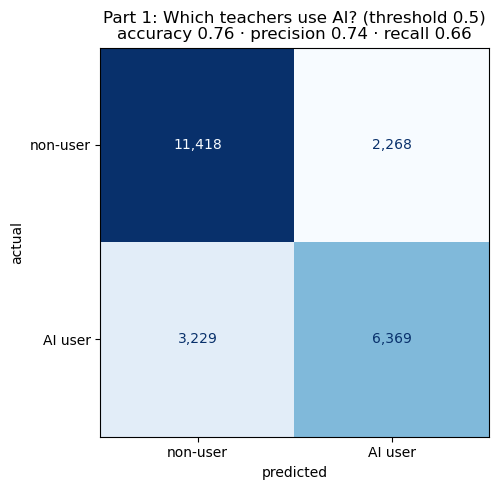

CNTRY      AUC    n
  CSH 0.694778  409
  AZE 0.707220  361
  AUT 0.728686  411
  KOR 0.732917  579
  TUR 0.742889 1061
  JPN 0.744256  582
  BGR 0.747126  280
  MLT 0.758838  227
  KAZ 0.769565  671
  ZAF 0.770298  242
  EST 0.775044  293
  MAR 0.775344  897
  SWE 0.790019  221
  ARE 0.790707 1065
  MKD 0.793340  328
  BHR 0.796346  336
  SVN 0.804138  786
  FRA 0.807135  391
  DNK 0.808185  377
  CRI 0.812622  286
  FIN 0.813674  368
  CHL 0.813810  202
  LTU 0.816617  411
  UZB 0.817452  430
  BFL 0.817937  598
  ISR 0.818860  258
  SAU 0.819265  667
  XKX 0.821956  270
  BFR 0.825477  445
  SRB 0.828092  362
  VNM 0.829812  433
  POL 0.830179  355
  COL 0.830825  287
  SVK 0.834300  386
  HUN 0.836127  337
  NZL 0.836446  240
  ESP 0.836503 1635
  HRV 0.837033  279
  BEL 0.837203  865
  BRA 0.838962  564
  PRT 0.841321  580
  ALB 0.843003  406
  ROU 0.844013  386
  LVA 0.850125  380
  AUS 0.856014  470
  CZE 0.856656  589
  ITA 0.868424  354

within-country AUC: median 0.817, min 0

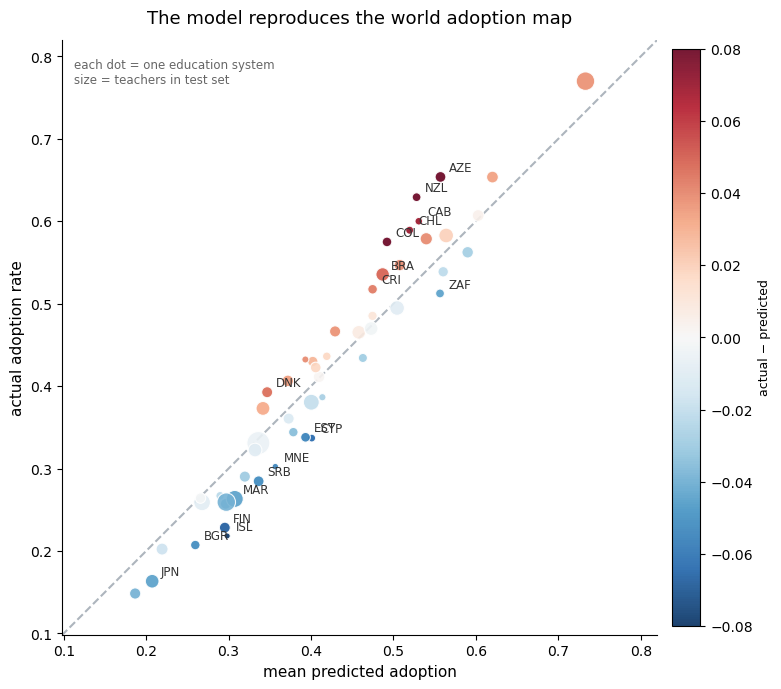


surprise adopters (model said no, adopted anyway): 635
surprise refusers (model said yes, didn't adopt):   302
T4TAGEGR         surpr-adopt 2.94 | surpr-refuse 2.66 | all 2.88
TT4G21G          surpr-adopt 0.02 | surpr-refuse 1.00 | all 0.41
ai_benefit_mean  surpr-adopt 2.26 | surpr-refuse 3.51 | all 2.77
prep_general     surpr-adopt 2.64 | surpr-refuse 3.13 | all 2.82

surprise refusers by country:
CNTRY
ARE    59
KAZ    18
CSH    15
ESP    13
ZAF    13
Name: count, dtype: int64


In [ ]:
# ============================================================
# CELL 15 — where does the model work? country slices + confusion matrix
# ============================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- 13a: confusion matrix at 0.5 threshold ---
best, best_feats, proba = fitted['A+T+B: +all beliefs']
te = test.copy(); te['proba'] = proba; te['resid'] = te['y'] - te['proba']
y_true = te['y'].astype(int)
y_pred = (te['proba'] >= 0.5).astype(int)


cm = confusion_matrix(y_true, y_pred)
tn, fp_, fn_, tp = cm.ravel()
acc  = (tp + tn) / cm.sum()
prec = tp / (tp + fp_)
rec  = tp / (tp + fn_)
print(f"\nWhich teachers use AI? (threshold 0.5):")
print(f"  accuracy {acc:.3f} | precision {prec:.3f} | recall {rec:.3f}")

fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=['non-user', 'AI user'])
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format=',d')
ax.set_title(f"Part 1: Which teachers use AI? (threshold 0.5)\n"
             f"accuracy {acc:.2f} · precision {prec:.2f} · recall {rec:.2f}")
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
plt.tight_layout()
plt.savefig(DATA_DIR / "output" / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


# --- 13b: per-country AUC (does the model work WITHIN countries?) ---
rows = [(c, roc_auc_score(g['y'], g['proba']), len(g))
        for c, g in te.groupby('CNTRY')
        if g['y'].nunique() == 2 and len(g) >= 200]
per_c = pd.DataFrame(rows, columns=['CNTRY', 'AUC', 'n']).sort_values('AUC')
print(per_c.to_string(index=False))
print(f"\nwithin-country AUC: median {per_c['AUC'].median():.3f}, "
      f"min {per_c['AUC'].min():.3f}, max {per_c['AUC'].max():.3f}")


# --- 13c: country predicted vs actual scatter ---
cg = te.groupby('CNTRY').agg(actual=('y','mean'), predicted=('proba','mean'), n=('y','size'))
cg['resid'] = cg['actual'] - cg['predicted']

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot([0, 1], [0, 1], color='#adb5bd', ls='--', lw=1.5, zorder=1)
sc = ax.scatter(cg['predicted'], cg['actual'], s=cg['n'] / 6,
                c=cg['resid'], cmap='RdBu_r', vmin=-0.08, vmax=0.08,
                edgecolors='white', linewidths=0.8, alpha=0.9, zorder=2)
for c, row in cg.iterrows():
    if abs(row['resid']) > 0.04:
        ax.annotate(c, (row['predicted'], row['actual']),
                    xytext=(6, 4), textcoords='offset points', fontsize=8.5, color='#333')
cb = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.02); cb.set_label("actual − predicted", fontsize=9)
lims = (cg[['predicted','actual']].min().min() - 0.05, cg[['predicted','actual']].max().max() + 0.05)
ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect('equal')
ax.set_xlabel("mean predicted adoption", fontsize=11)
ax.set_ylabel("actual adoption rate", fontsize=11)
ax.set_title("The model reproduces the world adoption map", fontsize=13, pad=12)
ax.text(0.02, 0.97, "each dot = one education system\nsize = teachers in test set",
        transform=ax.transAxes, va='top', fontsize=8.5, color='#666')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(DATA_DIR / "output" / "country_pred_vs_actual_pretty.png", dpi=150, bbox_inches="tight")
plt.show()


# --- 13d: misclassification autopsy ---
fn = te[(te['proba'] < 0.2) & (te['y'] == 1)]   # surprise adopters
fp = te[(te['proba'] > 0.8) & (te['y'] == 0)]   # surprise refusers
print(f"\nsurprise adopters (model said no, adopted anyway): {len(fn):,}")
print(f"surprise refusers (model said yes, didn't adopt):   {len(fp):,}")
for v in ['T4TAGEGR', 'TT4G21G', 'ai_benefit_mean', 'prep_general']:
    print(f"{v:16s} surpr-adopt {fn[v].mean():.2f} | surpr-refuse {fp[v].mean():.2f} | all {te[v].mean():.2f}")
print("\nsurprise refusers by country:"); print(fp['CNTRY'].value_counts().head(5))

Part 2 confusion matrix (threshold 0.5):
  accuracy 0.736 | precision 0.756 | recall 0.925


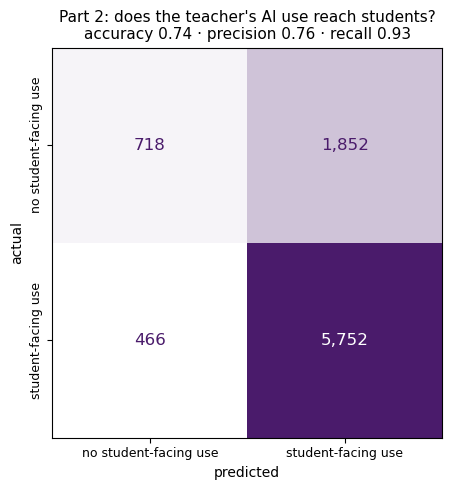

In [ ]:
# ============================================================
# CELL 16 — Part 2 confusion matrix (accurate labels, purple, smaller fonts)
# ============================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib.colors import LinearSegmentedColormap

y_true2 = test2['y'].astype(int)
y_pred2 = (proba2 >= 0.5).astype(int)

cm2 = confusion_matrix(y_true2, y_pred2)
tn, fp_, fn_, tp = cm2.ravel()
acc  = (tp + tn) / cm2.sum()
prec = tp / (tp + fp_)
rec  = tp / (tp + fn_)
print(f"Part 2 confusion matrix (threshold 0.5):")
print(f"  accuracy {acc:.3f} | precision {prec:.3f} | recall {rec:.3f}")

purple_cmap = LinearSegmentedColormap.from_list("purple", ["#ffffff", "#4A1B6B"])

fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(cm2,
        display_labels=['no student-facing use', 'student-facing use'])
disp.plot(ax=ax, cmap=purple_cmap, colorbar=False, values_format=',d')

# shrink the count numbers inside cells
for t in disp.text_.ravel():
    t.set_fontsize(12)

# shrink tick labels (the class names) and keep them on one line
ax.set_xticklabels(ax.get_xticklabels(), fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9, rotation=90, va='center')

ax.set_title(f"Part 2: does the teacher's AI use reach students?\n"
             f"accuracy {acc:.2f} · precision {prec:.2f} · recall {rec:.2f}",
             fontsize=11)
ax.set_xlabel("predicted", fontsize=10)
ax.set_ylabel("actual", fontsize=10)
plt.tight_layout()
plt.savefig(DATA_DIR / "output" / "part2_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

CNTRY      AUC   n
  SAU 0.529704 320
  ALB 0.537584 205
  BFL 0.570846 229
  KOR 0.592240 251
  UZB 0.596757 247
  ESP 0.611147 489
  CSH 0.629401 183
  TUR 0.629889 286
  DNK 0.638968 168
  SVN 0.639153 262
  CZE 0.643553 246
  AUS 0.661491 232
  POL 0.667087 156
  ARE 0.678428 791
  BEL 0.683642 227
  KAZ 0.690162 394
  VNM 0.692130 228
  BRA 0.701953 286
  PRT 0.712439 201
  AZE 0.715640 222
  MAR 0.729514 223
  ROU 0.824875 157

Part 2 within-country AUC: median 0.653, min 0.530, max 0.825
Part 2 pooled AUC: 0.745

THE CONTRAST — within-country vs pooled:
  Adoption:       within 0.818 | pooled 0.833  (gap 0.015)
  Student-facing: within 0.653 | pooled 0.745  (gap 0.093)


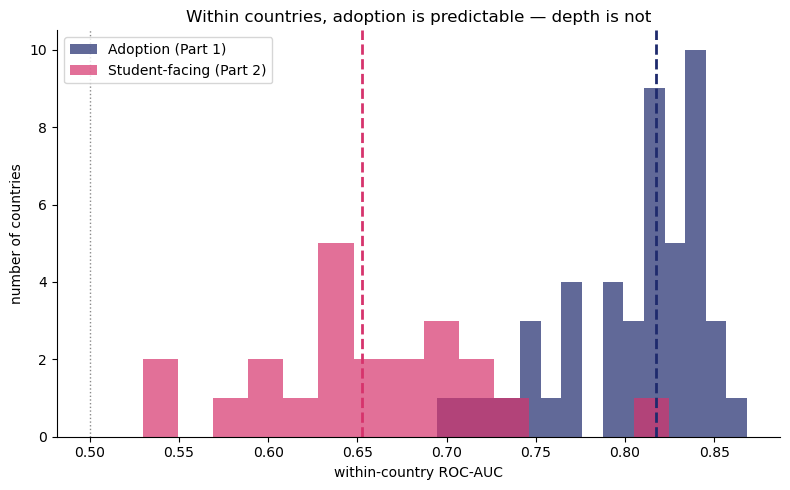

In [ ]:
# ============================================================
# CELL 17 (Part 2) — within-country AUC: the adoption-vs-depth contrast
# ============================================================
te2 = test2.copy(); te2['proba'] = proba2

rows2 = [(c, roc_auc_score(g['y'], g['proba']), len(g))
         for c, g in te2.groupby('CNTRY')
         if g['y'].nunique() == 2 and len(g) >= 150]
per_c2 = pd.DataFrame(rows2, columns=['CNTRY', 'AUC', 'n']).sort_values('AUC')
print(per_c2.to_string(index=False))

med2  = per_c2['AUC'].median()
pool2 = roc_auc_score(test2['y'], proba2)
print(f"\nPart 2 within-country AUC: median {med2:.3f}, "
      f"min {per_c2['AUC'].min():.3f}, max {per_c2['AUC'].max():.3f}")
print(f"Part 2 pooled AUC: {pool2:.3f}")

print("\n" + "="*50)
print("THE CONTRAST — within-country vs pooled:")
print(f"  Adoption:       within 0.818 | pooled 0.833  (gap 0.015)")
print(f"  Student-facing: within {med2:.3f} | pooled {pool2:.3f}  (gap {pool2-med2:.3f})")
print("="*50)


# ---- within-country AUC: adoption vs student-facing (THE contrast) ----
NAVY, ROSE = '#1E2A6D', '#D6336C'

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(per_c['AUC'], bins=15, alpha=0.7, color=NAVY, label='Adoption (Part 1)')
ax.hist(per_c2['AUC'], bins=15, alpha=0.7, color=ROSE, label='Student-facing (Part 2)')
ax.axvline(per_c['AUC'].median(), color=NAVY, ls='--', lw=2)
ax.axvline(per_c2['AUC'].median(), color=ROSE, ls='--', lw=2)
ax.axvline(0.5, color='#8A8A8A', ls=':', lw=1)
ax.set_xlabel("within-country ROC-AUC")
ax.set_ylabel("number of countries")
ax.set_title("Within countries, adoption is predictable — depth is not")
ax.legend()
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(DATA_DIR / "output" / "within_country_contrast.png", dpi=150, bbox_inches='tight')
plt.show()

## Are the model's probabilities honest? (calibration)

A model can rank teachers correctly (good AUC) yet still give *dishonest* probabilities — saying "70% likely" for teachers who actually adopt only 50% of
the time. Calibration checks this.

**Calibration curve (left).** We group teachers by predicted probability and plot predicted vs. what actually happened. If the model says "60%" and 60% of those teachers really adopted, the dot sits on the diagonal. Our dots hug the diagonal closely (Brier score 0.162, where lower is better) — so when the model says 70%, about 70% really do adopt. The probabilities mean what they say.

**Score distributions (right).** The two histograms show predicted scores for actual non-users (blue) vs. actual adopters (orange). They separate cleanly —
non-users pile up at low scores, adopters at high — which is the AUC of 0.833 made visual. The overlap in the middle is where the model is genuinely uncertain.

**Binned residuals (second plot).** We sort teachers into 20 bins by predicted probability and plot the average error (actual − predicted) in each. Points
scatter close to zero with a mild upward tilt: the model slightly over-predicts for its lowest-probability teachers and slightly under-predicts for its highest —
a gentle conservatism at the extremes. The magnitude is tiny (±0.04), so it doesn't affect the conclusions.

**Bottom line:** the model isn't just accurate, its probabilities are trustworthy, and its errors have no alarming pattern.

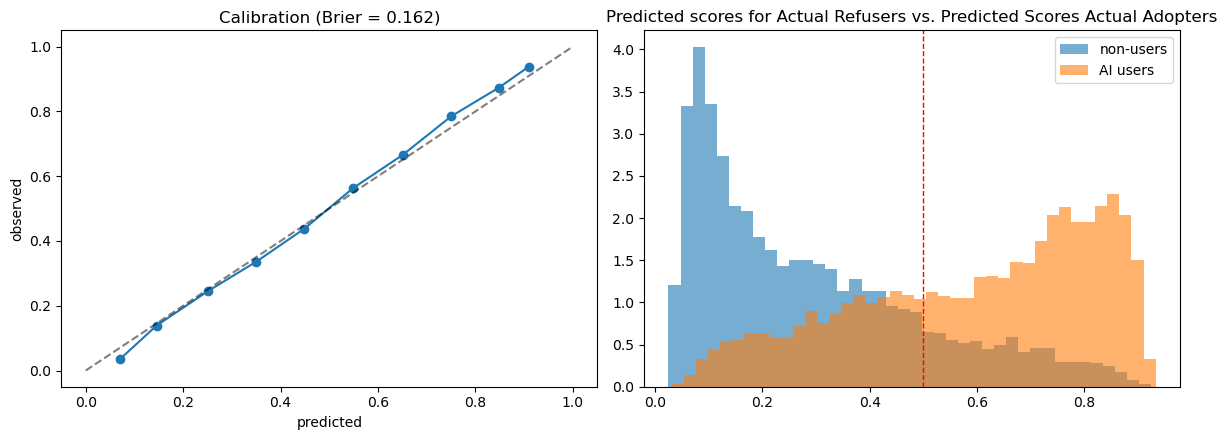

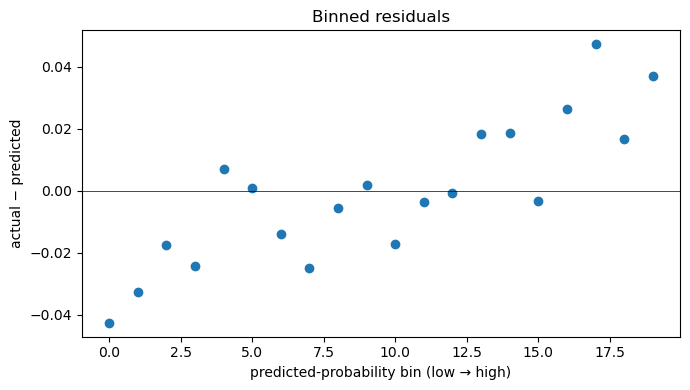

In [ ]:
# ============================================================
# CELL 18 — calibration + score distributions (Part 1 adoption model)
# ============================================================
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

best_name = 'A+T+B: +all beliefs'                  # ← fixed (was +S: +school context)
best, best_feats, proba = fitted[best_name]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
frac, mean_pred = calibration_curve(test['y'], proba, n_bins=10)
axes[0].plot(mean_pred, frac, 'o-'); axes[0].plot([0,1],[0,1],'k--',alpha=.5)
axes[0].set_title(f"Calibration (Brier = {brier_score_loss(test['y'], proba):.3f})")
axes[0].set_xlabel("predicted"); axes[0].set_ylabel("observed")

axes[1].hist(proba[test['y']==0], bins=40, density=True, alpha=.6, label='non-users')
axes[1].hist(proba[test['y']==1], bins=40, density=True, alpha=.6, label='AI users')
axes[1].axvline(0.5, color='red', ls='--', lw=1)
axes[1].set_title("Predicted scores for Actual Refusers vs. Predicted Scores Actual Adopters"); axes[1].legend()
plt.tight_layout()
plt.savefig(DATA_DIR / "output" / "calibration_scores.png", dpi=150)
plt.show()

# CELL 13b — binned residuals
te = test.copy(); te['proba'] = proba; te['resid'] = te['y'] - te['proba']
br = te.groupby(pd.qcut(te['proba'], 20), observed=True)['resid'].mean()
plt.figure(figsize=(7, 4))
plt.axhline(0, color='k', lw=.5)
plt.scatter(range(len(br)), br.values)
plt.xlabel("predicted-probability bin (low → high)"); plt.ylabel("actual − predicted")
plt.title("Binned residuals")
plt.tight_layout(); plt.show()

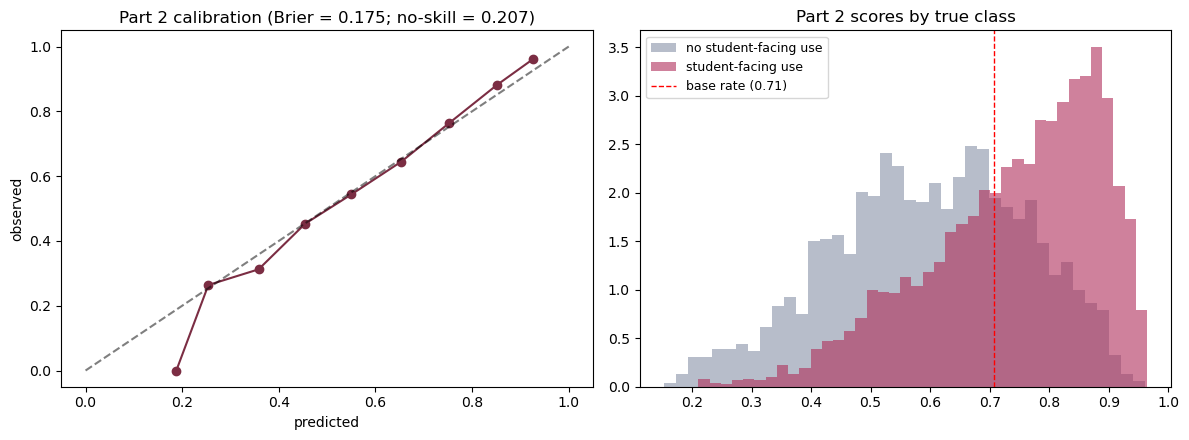

Part 2 Brier 0.175 vs no-skill 0.207 -> skill score 0.15


In [ ]:


# ============================================================
# CELL 19 — Part 2 calibration + score distributions
# Mirrors CELL 12 for the student-facing model.
# Requires: proba2, test2 (CELL 9)
# ============================================================
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

base2 = test2['y'].mean()
brier2 = brier_score_loss(test2['y'], proba2)
brier_ref2 = base2 * (1 - base2)          # always-predict-base-rate Brier

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
frac2, mean_pred2 = calibration_curve(test2['y'], proba2, n_bins=10)
axes[0].plot(mean_pred2, frac2, 'o-', color='#7b2d43')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=.5)
axes[0].set_title(f"Part 2 calibration (Brier = {brier2:.3f}; "
                  f"no-skill = {brier_ref2:.3f})")
axes[0].set_xlabel("predicted"); axes[0].set_ylabel("observed")

axes[1].hist(proba2[test2['y'] == 0], bins=40, density=True, alpha=.6,
             label='no student-facing use', color='#8891a8')
axes[1].hist(proba2[test2['y'] == 1], bins=40, density=True, alpha=.6,
             label='student-facing use', color='#b02e5a')
axes[1].axvline(base2, color='red', ls='--', lw=1,
                label=f'base rate ({base2:.2f})')
axes[1].set_title("Part 2 scores by true class")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(DATA_DIR / "output" / "calibration_scores_part2.png", dpi=150)
plt.show()

print(f"Part 2 Brier {brier2:.3f} vs no-skill {brier_ref2:.3f} "
      f"-> skill score {1 - brier2 / brier_ref2:.2f}")

## Part 2 performance: ROC and precision-recall

We evaluate the student-facing model two ways, because the outcome is imbalanced
(~70% of AI-users are student-facing):

- **ROC-AUC = 0.746** — the model ranks a random student-facing teacher above a
  random teacher-facing-only teacher 75% of the time. This is our headline
  metric: it's independent of the base rate and directly comparable to Part 1's
  adoption model (0.833).
- **Precision-recall (AP = 0.871)** — precision stays high across recall levels,
  but note the base rate (dashed line at 0.70): "always predict student-facing"
  already achieves ~70% precision, so the model's improvement is over that
  majority-class baseline, not over a coin flip.

**Reading the result.** Student-facing use is predictable, but *less* predictable
than adoption (0.746 vs 0.833). That gap is itself a finding: adoption is an
individual-readiness decision that teacher characteristics capture well, while
depth of use is shaped more by context — national norms, school policy, classroom
access — that this survey doesn't directly measure. The steep early rise in the
ROC curve shows the model is confident and correct on the clear cases; the
flatter middle reflects the borderline teachers whose behaviour depends on
factors beyond individual traits.

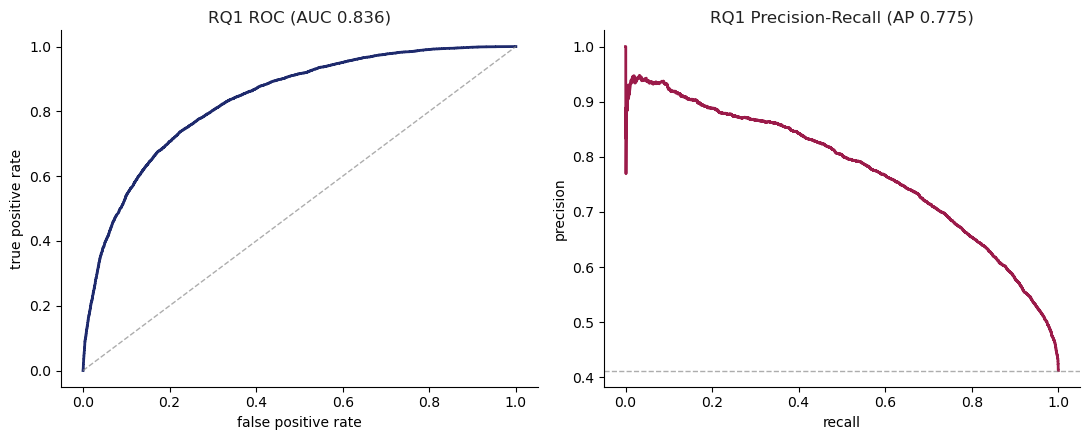

In [40]:
# ============================================================
# CELL 20 — ROC and Precision Recall curves for Part 1 Model
# Mirrors CELL 17 (Part 2). Part 1 proba pulled EXPLICITLY from
# `fitted` — the Part 2 cell reuses the bare name `proba`.
# ============================================================
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

# deck palette (Part 1: navy / maroon)
NAVY, MAROON, GRAY = '#1E2A6D', '#9B1B4A', '#8A8A8A'

_, _, proba1 = fitted['A+T+B: +all beliefs']

fpr, tpr, _ = roc_curve(test['y'], proba1)
prec, rec, _ = precision_recall_curve(test['y'], proba1)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

# ROC
ax[0].plot(fpr, tpr, color=NAVY, lw=2)
ax[0].plot([0, 1], [0, 1], color=GRAY, ls='--', lw=1, alpha=.7)
ax[0].set_title(f"RQ1 ROC (AUC {roc_auc_score(test['y'], proba1):.3f})", color='#222')
ax[0].set_xlabel("false positive rate"); ax[0].set_ylabel("true positive rate")

# Precision-Recall
ax[1].plot(rec, prec, color=MAROON, lw=2)
ax[1].axhline(test['y'].mean(), color=GRAY, ls='--', lw=1, alpha=.7)
ax[1].set_title(f"RQ1 Precision-Recall (AP {average_precision_score(test['y'], proba1):.3f})", color='#222')
ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision")

for a in ax:
    for spine in ['top', 'right']:
        a.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(DATA_DIR / "output" / "part1_roc_pr.png", dpi=150, bbox_inches='tight')
plt.show()

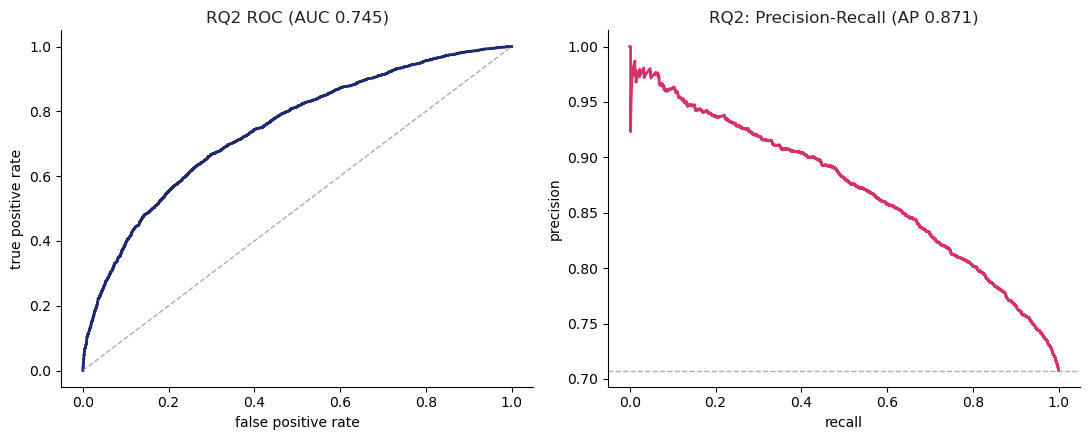

In [41]:

# ============================================================
# CELL 21 — ROC and Precision Recall curves for Part 2 Model
# ============================================================

from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

# deck palette
NAVY, ROSE, GRAY = '#1E2A6D', '#D6336C', '#8A8A8A'

fpr, tpr, _ = roc_curve(test2['y'], proba2)
prec, rec, _ = precision_recall_curve(test2['y'], proba2)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

# ROC
ax[0].plot(fpr, tpr, color=NAVY, lw=2)
ax[0].plot([0, 1], [0, 1], color=GRAY, ls='--', lw=1, alpha=.7)
ax[0].set_title(f"RQ2 ROC (AUC {roc_auc_score(test2['y'], proba2):.3f})", color='#222')
ax[0].set_xlabel("false positive rate"); ax[0].set_ylabel("true positive rate")

# Precision-Recall
ax[1].plot(rec, prec, color=ROSE, lw=2)
ax[1].axhline(test2['y'].mean(), color=GRAY, ls='--', lw=1, alpha=.7)
ax[1].set_title(f"RQ2: Precision-Recall (AP {average_precision_score(test2['y'], proba2):.3f})", color='#222')
ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision")

for a in ax:
    for spine in ['top', 'right']:
        a.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(DATA_DIR / "output" / "part2_roc_pr.png", dpi=150, bbox_inches='tight')
plt.show()

In [42]:
# ============================================================
# CELL 22 — Part 2 logistic coefficients with inference
# statsmodels Logit, school-clustered SEs, per-SD odds ratios
# Requires: data2 (CELL 15), CATEGORICALS
# ============================================================
import statsmodels.api as sm

feats2b = feature_sets['A+T+B: +all beliefs']
num_feats = [f for f in feats2b if f not in CATEGORICALS]
cat_feats = [f for f in feats2b if f in CATEGORICALS]

# Inference uses the full Part 2 analytic sample (not just train):
# we're estimating population associations, not measuring generalization.
X = data2[feats2b].copy()

# standardize numeric features -> coefficients are per-SD, comparable
X[num_feats] = (X[num_feats] - X[num_feats].mean()) / X[num_feats].std()

# one-hot categoricals; drop_first fixes a reference category
X = pd.get_dummies(X, columns=cat_feats, drop_first=True, dtype=float)
X = sm.add_constant(X)
y = data2['y'].astype(float)

model = sm.Logit(y, X)

# CRITICAL: teachers are clustered in schools; naive SEs would be
# too small and p-values too optimistic. Cluster by school.
res = model.fit(disp=0, cov_type='cluster',
                cov_kwds={'groups': data2['IDSCHOOL']})

# tidy table: per-SD odds ratios with 95% CIs, teacher features only
# (country dummies reported separately — they're vs the reference country)
tab = pd.DataFrame({
    'OR_per_SD': np.exp(res.params),
    'CI_low':    np.exp(res.conf_int()[0]),
    'CI_high':   np.exp(res.conf_int()[1]),
    'p':         res.pvalues,
})
teacher_rows = [i for i in tab.index
                if not i.startswith('CNTRY_') and i != 'const']
teacher_tab = (tab.loc[teacher_rows]
                  .sort_values('OR_per_SD', ascending=False)
                  .round(3))
print("Teacher-level effects (odds ratios per SD, school-clustered SEs):")
print(teacher_tab.to_string())

print(f"\nMcFadden pseudo-R2: {res.prsquared:.3f}")
print(f"n = {int(res.nobs):,} teachers, "
      f"{data2['IDSCHOOL'].nunique():,} school clusters")

# spread of country effects (log-odds SD across dummies) — one number
# summarizing how much 'context' varies, vs any single teacher effect
cntry_rows = [i for i in tab.index if i.startswith('CNTRY_')]
print(f"\ncountry fixed effects: {len(cntry_rows)} dummies, "
      f"log-odds SD = {res.params[cntry_rows].std():.2f} "
      f"(compare to largest |teacher log-odds| = "
      f"{res.params[teacher_rows].abs().max():.2f})")

Teacher-level effects (odds ratios per SD, school-clustered SEs):
                 OR_per_SD  CI_low  CI_high      p
ai_benefit_mean      1.384   1.341    1.429  0.000
T4COLES              1.229   1.189    1.271  0.000
T4TAGEGR             1.214   1.176    1.253  0.000
TT4G21G              1.137   1.104    1.170  0.000
T4VALP               1.115   1.074    1.158  0.000
TT4G27M              1.112   1.079    1.147  0.000
TT4G07F              1.081   1.039    1.126  0.000
T4TNSCH              1.060   1.029    1.092  0.000
prep_general         1.059   1.017    1.103  0.006
T4TEMPWH_2.0         1.049   0.965    1.140  0.265
TT4G15               1.047   1.016    1.079  0.003
T4TLEAD              1.045   1.011    1.080  0.010
T4STBEH              1.023   0.989    1.059  0.188
T4WLOADT             1.013   0.978    1.049  0.469
T4CHFAT              1.010   0.979    1.042  0.538
ai_risk_mean         0.961   0.931    0.991  0.012
T4JOBSAT             0.952   0.918    0.987  0.008

McFadden pseudo

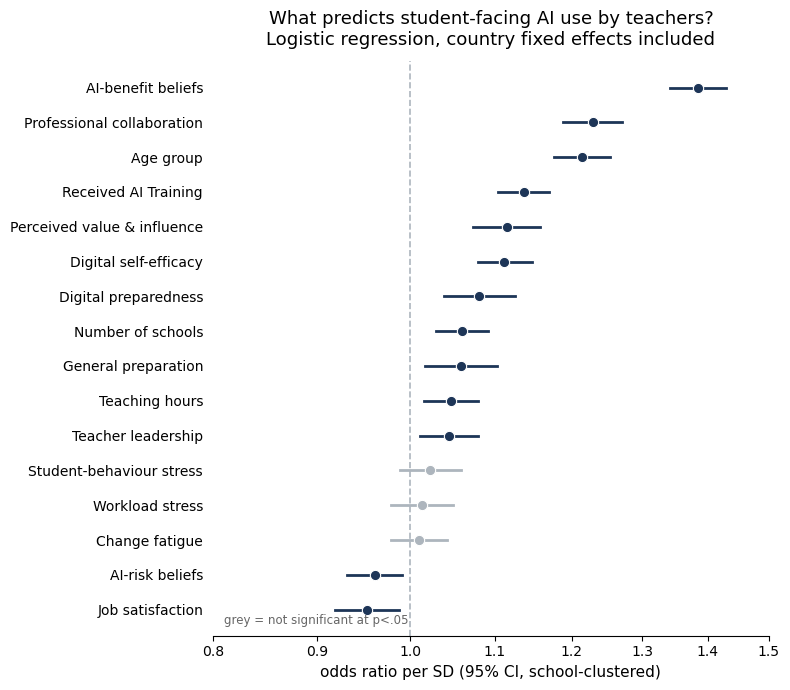

In [43]:
# ============================================================
# CELL 23 — forest plot of teacher-level odds ratios (slide)
# Requires: teacher_tab, withlabels (from CELL 16b / CELL 10)
# ============================================================

ft = teacher_tab.copy()

# drop the T4TEMPWH dummies: codes 8/9 are missing codes that leaked
# into the encoding (fix upstream later); 2.0 is n.s. and unlabeled
ft = ft[~ft.index.str.startswith('T4TEMPWH')]

ft = ft.sort_values('OR_per_SD')                     # smallest at bottom
labels = [withlabels.get(f, f) for f in ft.index]
sig = ft['p'] < 0.05

fig, ax = plt.subplots(figsize=(8, 7))
ypos = np.arange(len(ft))

ax.axvline(1.0, color='#adb5bd', ls='--', lw=1.2, zorder=1)

for i, (idx, row) in enumerate(ft.iterrows()):
    color = '#1d3557' if sig.iloc[i] else '#adb5bd'
    ax.plot([row['CI_low'], row['CI_high']], [i, i],
            color=color, lw=2, zorder=2)
    ax.scatter(row['OR_per_SD'], i, s=55, color=color,
               edgecolors='white', linewidths=0.8, zorder=3)

ax.set_yticks(ypos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xscale('log')                                 # symmetric ORs
ax.set_xticks([0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
ax.set_xticklabels(['0.8', '0.9', '1.0', '1.1', '1.2', '1.3', '1.4', '1.5'])
ax.set_xlabel("odds ratio per SD (95% CI, school-clustered)", fontsize=11)
ax.set_title("What predicts student-facing AI use by teachers?\n"
             "Logistic regression, country fixed effects included",
             fontsize=13, pad=12)
ax.text(0.02, 0.02, "grey = not significant at p<.05",
        transform=ax.transAxes, fontsize=8.5, color='#666')
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)

plt.tight_layout()
plt.savefig(DATA_DIR / "output" / "forest_plot_part2_ors.png",
            dpi=200, bbox_inches='tight')
plt.show()

Odds ratios per SD [95% CI], school-clustered SEs
* p<.05  ** p<.01  *** p<.001   (country FE + employment status included)
                                    Adoption (P1) Student-facing use (P2)
AI-benefit beliefs           2.31 [2.25, 2.37]***    1.38 [1.34, 1.43]***
Received AI Training         2.02 [1.98, 2.06]***    1.14 [1.10, 1.17]***
Digital self-efficacy        1.25 [1.23, 1.28]***    1.11 [1.08, 1.15]***
Professional collaboration   1.10 [1.08, 1.13]***    1.23 [1.19, 1.27]***
Digital preparedness         1.10 [1.07, 1.13]***    1.08 [1.04, 1.13]***
Workload stress              1.07 [1.05, 1.10]***       1.01 [0.98, 1.05]
Number of schools              1.02 [1.00, 1.04]*    1.06 [1.03, 1.09]***
Change fatigue                  1.01 [0.99, 1.03]       1.01 [0.98, 1.04]
Job satisfaction                1.01 [0.99, 1.03]     0.95 [0.92, 0.99]**
Teaching hours                  1.00 [0.98, 1.02]     1.05 [1.02, 1.08]**
Student-behaviour stress     0.96 [0.94, 0.98]***       1.02 [

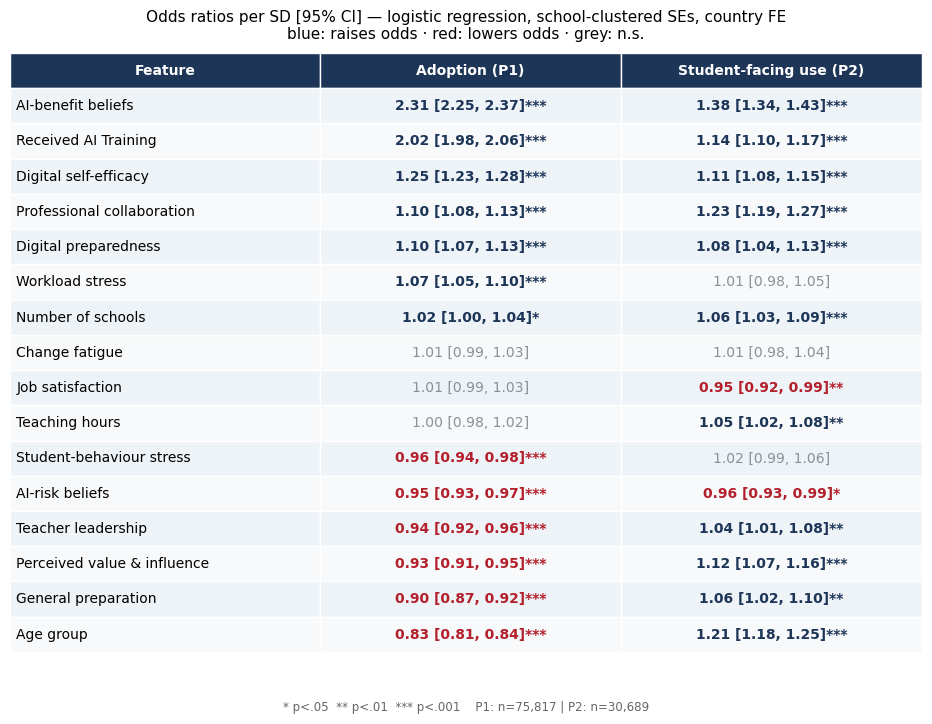

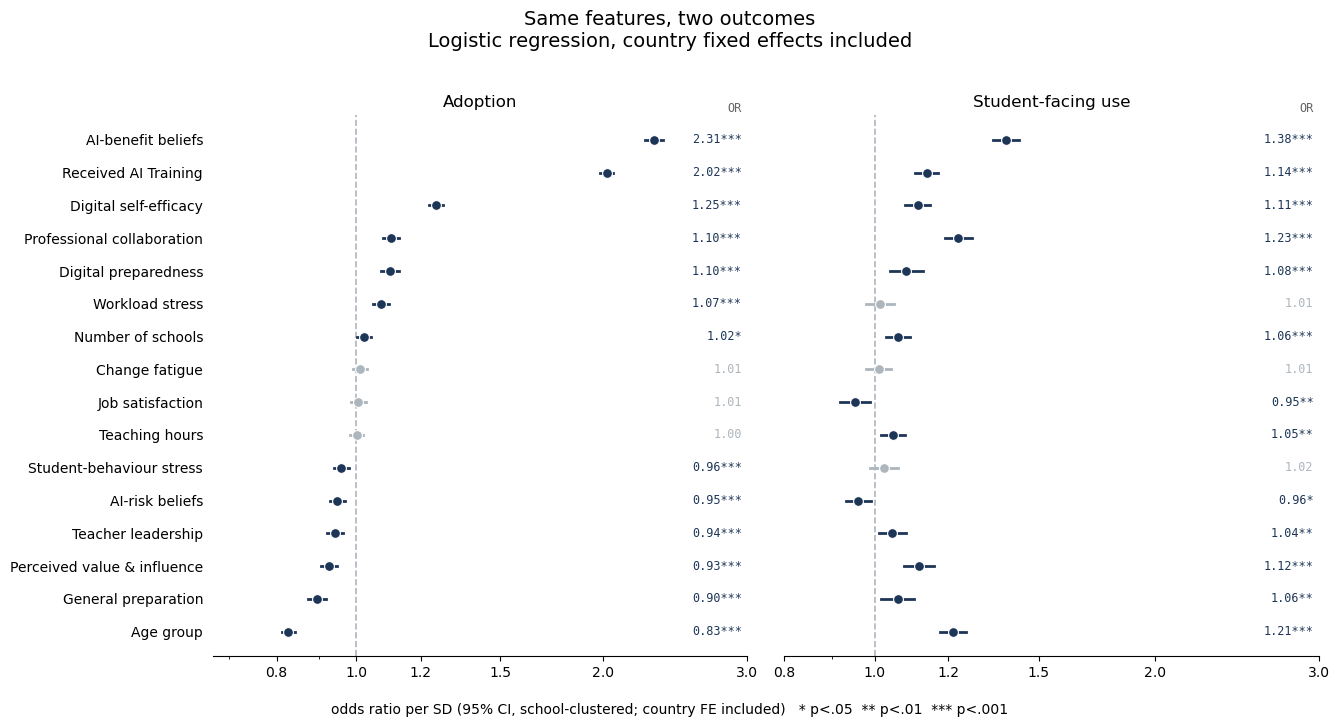

In [39]:
# ============================================================
# CELL 24 — clustered logit for BOTH parts:
#   starred coefficient table (OR [95% CI]) + paired forest plot
# Requires: data (P1), data2 (P2), feature_sets, CATEGORICALS,
#           withlabels, statsmodels
# ============================================================
import statsmodels.api as sm

FEATS = feature_sets['A+T+B: +all beliefs']


def clustered_logit(df, outcome='y', cluster='IDSCHOOL'):
    """Standardized clustered logit; returns tidy OR table."""
    num = [f for f in FEATS if f not in CATEGORICALS]
    cat = [f for f in FEATS if f in CATEGORICALS]

    d = df[FEATS + [outcome, cluster]].copy()
    # local guard until upstream fix: mask T4TEMPWH missing codes
    if 'T4TEMPWH' in d.columns:
        d['T4TEMPWH'] = pd.to_numeric(d['T4TEMPWH'], errors='coerce') \
                          .where(lambda s: ~s.isin([8, 9]))
    d = d.dropna()

    X = d[FEATS].copy()
    X[num] = (X[num] - X[num].mean()) / X[num].std()
    X = pd.get_dummies(X, columns=cat, drop_first=True, dtype=float)
    X = sm.add_constant(X)

    res = sm.Logit(d[outcome].astype(float), X).fit(
        disp=0, cov_type='cluster', cov_kwds={'groups': d[cluster]})

    tab = pd.DataFrame({
        'OR': np.exp(res.params),
        'lo': np.exp(res.conf_int()[0]),
        'hi': np.exp(res.conf_int()[1]),
        'p':  res.pvalues,
    })
    tab.attrs['n'] = int(res.nobs)
    tab.attrs['clusters'] = d[cluster].nunique()
    tab.attrs['pseudo_r2'] = res.prsquared
    return tab


def stars(p):
    return '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else ''


def fmt(tab):
    """'1.39 [1.34, 1.43]***' per row."""
    return tab.apply(lambda r: f"{r['OR']:.2f} [{r['lo']:.2f}, "
                               f"{r['hi']:.2f}]{stars(r['p'])}", axis=1)


t1 = clustered_logit(data,  outcome='y')     # P1: adoption
t2 = clustered_logit(data2, outcome='y')     # P2: student-facing use

keep = [i for i in t1.index
        if i != 'const' and not i.startswith(('CNTRY_', 'T4TEMPWH_'))]

table = pd.DataFrame({
    'Adoption (P1)':          fmt(t1.loc[keep]),
    'Student-facing use (P2)': fmt(t2.reindex(keep)),
})
table.index = [withlabels.get(f, f) for f in keep]
# order by Part 1 effect size
order = t1.loc[keep, 'OR'].sort_values(ascending=False).index
table = table.loc[[withlabels.get(f, f) for f in order]]

print("Odds ratios per SD [95% CI], school-clustered SEs")
print("* p<.05  ** p<.01  *** p<.001   (country FE + employment status included)")
print(table.to_string())
print(f"\nP1: n={t1.attrs['n']:,}, {t1.attrs['clusters']:,} schools, "
      f"pseudo-R2={t1.attrs['pseudo_r2']:.3f}")
print(f"P2: n={t2.attrs['n']:,}, {t2.attrs['clusters']:,} schools, "
      f"pseudo-R2={t2.attrs['pseudo_r2']:.3f}")

table.to_csv(DATA_DIR / "output" / "coef_table_both_parts.csv")

# ---------- rendered table (PNG for slides/README) ----------
n_rows = len(table)
fig_t, ax_t = plt.subplots(figsize=(9.5, 0.38 * n_rows + 1.8))
ax_t.axis('off')

cell_text = [[idx, r['Adoption (P1)'], r['Student-facing use (P2)']]
             for idx, r in table.iterrows()]
tbl = ax_t.table(cellText=cell_text,
                 colLabels=['Feature', 'Adoption (P1)',
                            'Student-facing use (P2)'],
                 colWidths=[0.34, 0.33, 0.33],
                 cellLoc='center',
                 bbox=[0, 0, 1, 1])          # fill the axes exactly
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)

# direction + significance coloring:
#   blue  = OR > 1 (raises odds), red = OR < 1 (lowers odds),
#   grey  = CI crosses 1 / p >= .05
raw = {'Adoption (P1)': t1.loc[order],
       'Student-facing use (P2)': t2.reindex(order)}
col_of = {1: 'Adoption (P1)', 2: 'Student-facing use (P2)'}

for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('white')
    if r == 0:                                   # header
        cell.set_facecolor('#1d3557')
        cell.set_text_props(color='white', fontweight='bold')
        continue
    cell.set_facecolor('#eef3f8' if r % 2 else '#f8f9fa')
    if c == 0:
        cell.set_text_props(ha='left')
        cell.PAD = 0.02
    else:
        row = raw[col_of[c]].iloc[r - 1]
        if row['p'] >= .05:
            cell.set_text_props(color='#8a8f98')
        elif row['OR'] > 1:
            cell.set_text_props(color='#1d3557', fontweight='bold')
        else:
            cell.set_text_props(color='#b3202c', fontweight='bold')

ax_t.set_title("Odds ratios per SD [95% CI] — "
               "logistic regression, school-clustered SEs, country FE\n"
               "blue: raises odds · red: lowers odds · grey: n.s.",
               fontsize=11, pad=10)
fig_t.text(0.5, 0.015,
           f"* p<.05  ** p<.01  *** p<.001    "
           f"P1: n={t1.attrs['n']:,} | P2: n={t2.attrs['n']:,}",
           ha='center', fontsize=8.5, color='#666')

fig_t.subplots_adjust(left=0.02, right=0.98, top=0.85, bottom=0.09)
plt.savefig(DATA_DIR / "output" / "coef_table_both_parts.png",
            dpi=200, bbox_inches='tight')
plt.show()


# ---------- paired forest plot ----------
f1, f2 = t1.loc[order], t2.reindex(order)
labels = [withlabels.get(f, f) for f in order][::-1]
ypos = np.arange(len(order))

import matplotlib.transforms as mtransforms

fig, axes = plt.subplots(1, 2, figsize=(13.5, 7), sharey=True)
for ax, tt, title in [(axes[0], f1[::-1], 'Adoption'),
                      (axes[1], f2[::-1], 'Student-facing use')]:
    ax.axvline(1.0, color='#adb5bd', ls='--', lw=1.2, zorder=1)
    # blended transform: x in axes fraction, y in data coords
    trans = mtransforms.blended_transform_factory(ax.transAxes, ax.transData)
    for i, (_, row) in enumerate(tt.iterrows()):
        c = '#1d3557' if row['p'] < .05 else '#adb5bd'
        ax.plot([row['lo'], row['hi']], [i, i], color=c, lw=2, zorder=2)
        ax.scatter(row['OR'], i, s=50, color=c,
                   edgecolors='white', linewidths=0.8, zorder=3)
        # annotation column: OR with stars, right-aligned inside the panel
        ax.text(0.99, i, f"{row['OR']:.2f}{stars(row['p'])}",
                transform=trans, ha='right', va='center',
                fontsize=8.5, color=c, family='monospace')
    # column header above the annotation strip
    ax.text(0.99, len(tt) - 0.25, "OR", transform=trans,
            ha='right', va='bottom', fontsize=8.5, color='#666',
            family='monospace')
    ax.set_xscale('log')
    ax.set_title(title, fontsize=12)
    ax.margins(x=0.18)          # room on the right for the text column
    for sp in ['top', 'right', 'left']:
        ax.spines[sp].set_visible(False)
    ax.tick_params(left=False)

# shared log-x ticks across both panels
xt = [0.8, 1.0, 1.2, 1.5, 2.0, 3.0]
for ax in axes:
    ax.set_xticks(xt); ax.set_xticklabels([str(x) for x in xt])
axes[0].set_yticks(ypos); axes[0].set_yticklabels(labels, fontsize=10)
fig.supxlabel("odds ratio per SD (95% CI, school-clustered; country FE included)   "
              "* p<.05  ** p<.01  *** p<.001",
              fontsize=10)
fig.suptitle("Same features, two outcomes\n"
             "Logistic regression, country fixed effects included",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / "output" / "forest_plot_both_parts.png",
            dpi=200, bbox_inches='tight')
plt.show()